# 코드와 무관한 url
https://workspace.google.com/marketplace
-> 프롬프트 다 확인
# 1. 코드 A
- 기본 함수 정의 (rastrigin, ackley + grad, BENCHMARKS)
       
  → 모든 실험의 베이스

Rastrigin best value: 240.46975609055454
Rosenbrock best value: 325072.72945024725
Ackley best value: 4.7366621177254835


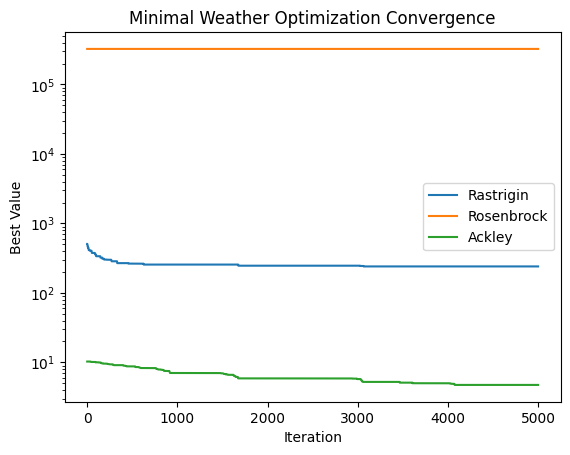

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# Benchmark Functions
# ==========================================

def rastrigin(x):
    A = 10
    d = len(x)
    return A * d + np.sum(x**2 - A * np.cos(2 * np.pi * x))


def rastrigin_grad(x):
    return 2*x + 2*np.pi*10*np.sin(2*np.pi*x)


def rosenbrock(x):
    return np.sum(100*(x[1:] - x[:-1]**2)**2 + (1-x[:-1])**2)


def rosenbrock_grad(x):
    grad = np.zeros_like(x)
    grad[0:-1] = -400*x[:-1]*(x[1:] - x[:-1]**2) - 2*(1-x[:-1])
    grad[1:] += 200*(x[1:] - x[:-1]**2)
    return grad


def ackley(x):
    d = len(x)
    a = 20
    b = 0.2
    c = 2*np.pi

    s1 = np.sum(x**2)
    s2 = np.sum(np.cos(c*x))

    term1 = -a*np.exp(-b*np.sqrt(s1/d))
    term2 = -np.exp(s2/d)

    return term1 + term2 + a + np.e


def ackley_grad(x):
    # numerical gradient (simpler)
    eps = 1e-8
    grad = np.zeros_like(x)

    for i in range(len(x)):
        x1 = x.copy()
        x2 = x.copy()
        x1[i] += eps
        x2[i] -= eps
        grad[i] = (ackley(x1) - ackley(x2)) / (2*eps)

    return grad


# ==========================================
# Minimal Weather Optimization
# ==========================================

class MinimalWO:

    def __init__(
        self,
        func,
        grad,
        dim,
        bounds,
        eta=0.01,
        sigma=0.05,
        stagnation_window=50,
        stagnation_tol=1e-6,
        restart_radius=1.0,
        max_iter=5000,
        seed=None
    ):

        self.func = func
        self.grad = grad
        self.dim = dim
        self.lower, self.upper = bounds

        self.eta = eta
        self.sigma = sigma
        self.window = stagnation_window
        self.tol = stagnation_tol
        self.restart_radius = restart_radius
        self.max_iter = max_iter

        if seed is not None:
            np.random.seed(seed)

    def optimize(self):

        x = np.random.uniform(self.lower, self.upper, self.dim)
        best = x.copy()

        best_val = self.func(x)

        history = []
        improvement_buffer = []

        for t in range(self.max_iter):

            g = self.grad(x)

            noise = np.random.normal(0, 1, self.dim)

            x = x - self.eta * g + self.sigma * noise

            x = np.clip(x, self.lower, self.upper)

            val = self.func(x)

            if val < best_val:
                best_val = val
                best = x.copy()

            history.append(best_val)

            # stagnation check
            improvement_buffer.append(val)

            if len(improvement_buffer) > self.window:

                old_val = improvement_buffer.pop(0)

                if abs(val - old_val) < self.tol:

                    # restart near best
                    delta = np.random.uniform(
                        -self.restart_radius,
                        self.restart_radius,
                        self.dim
                    )

                    x = best + delta
                    x = np.clip(x, self.lower, self.upper)

        return best, best_val, history


# ==========================================
# Benchmark Runner
# ==========================================

def run_benchmark(func, grad, name):

    dim = 30

    optimizer = MinimalWO(
        func=func,
        grad=grad,
        dim=dim,
        bounds=(-5,5),
        eta=0.01,
        sigma=0.05,
        stagnation_window=50,
        restart_radius=0.5,
        max_iter=5000,
        seed=42
    )

    best, value, history = optimizer.optimize()

    print(f"{name} best value:", value)

    return history


# ==========================================
# Run Experiments
# ==========================================

h1 = run_benchmark(rastrigin, rastrigin_grad, "Rastrigin")
h2 = run_benchmark(rosenbrock, rosenbrock_grad, "Rosenbrock")
h3 = run_benchmark(ackley, ackley_grad, "Ackley")


# ==========================================
# Convergence Plot
# ==========================================

plt.figure()

plt.plot(h1, label="Rastrigin")
plt.plot(h2, label="Rosenbrock")
plt.plot(h3, label="Ackley")

plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel("Best Value")

plt.title("Minimal Weather Optimization Convergence")

plt.legend()
plt.show()

In [ ]:
import numpy as np

In [ ]:
import numpy as np

# ============================================================
# Benchmark Functions
# ============================================================

def rastrigin(X):
    A = 10
    return A * X.shape[1] + np.sum(X**2 - A * np.cos(2 * np.pi * X), axis=1)

def rastrigin_grad(X):
    return 2*X + 20*np.pi*np.sin(2*np.pi*X)

def ackley(X):
    a, b, c = 20, 0.2, 2*np.pi
    D = X.shape[1]
    t1 = -a * np.exp(-b * np.sqrt(np.mean(X**2, axis=1)))
    t2 = -np.exp(np.mean(np.cos(c * X), axis=1))
    return t1 + t2 + a + np.e

def ackley_grad(X):
    a, b, c = 20, 0.2, 2*np.pi
    D = X.shape[1]
    r = np.sqrt(np.mean(X**2, axis=1) + 1e-12)
    coeff1 = (a * b * np.exp(-b * r) / (r * D))[:, None]
    coeff2 = (np.exp(np.mean(np.cos(c * X), axis=1)) * c / D)[:, None]
    return coeff1 * X + coeff2 * np.sin(c * X)

def sphere(X):
    return np.sum(X**2, axis=1)

def sphere_grad(X):
    return 2*X

BENCHMARKS = {
    "Rastrigin": (rastrigin, rastrigin_grad, -5.12,  5.12),
    "Ackley":    (ackley,    ackley_grad,    -32.0,  32.0),
    "Sphere":    (sphere,    sphere_grad,    -5.12,  5.12),
}

# ============================================================
# Weather Optimization
# ============================================================

def weather_optimize(
    func, grad_func,
    lower=-5.12, upper=5.12,
    D=10, N=80, iterations=2000,
    eta=0.01,
    eta_decay=0.6,
    epsilon_L_ratio=0.05,
    beta=0.99,        # ★ 최적값
    alpha=0.1,
    grad_tau=5.0,     # ★ 최적값
    thresh_k=0.5,     # ★ 최적값
    storm_fraction_start=0.5,
    storm_fraction_end=0.1,
    storm_cooldown=8,
    min_density=0.025,
    seed=0,
    verbose=False,
    return_history=False,
):
    rng = np.random.default_rng(seed)

    # 🌧 비: 초기 배치
    particles = rng.uniform(lower, upper, (N, D))
    energies = np.zeros(N)
    last_storm_iter = np.full(N, -999)
    total_storms = 0
    history = []

    for t in range(iterations):

        # 🌊 물 흐름: Gradient Descent
        eta_t = eta * (1 - eta_decay * t / iterations)
        grads = grad_func(particles)
        grad_norms_raw = np.linalg.norm(grads, axis=1)
        grads_clipped = grads / np.maximum(grad_norms_raw[:, None] + 1e-8, 1.0)
        particles -= eta_t * grads_clipped
        particles = np.clip(particles, lower, upper)

        losses = func(particles)

        # 정체 판정: grad_norm < grad_tau → stuck
        stuck_mask = (grad_norms_raw < grad_tau).astype(float)

        # 🌍 순환: Loss-space 클러스터링
        epsilon_L = epsilon_L_ratio * (np.max(losses) - np.min(losses) + 1e-8)
        sorted_idx = np.argsort(losses)
        sorted_L = losses[sorted_idx]

        clusters = []
        current = [sorted_idx[0]]
        for k in range(1, N):
            if sorted_L[k] - sorted_L[k-1] < epsilon_L:
                current.append(sorted_idx[k])
            else:
                if len(current) > 1:
                    clusters.append(np.array(current))
                current = [sorted_idx[k]]
        if len(current) > 1:
            clusters.append(np.array(current))

        # 🌬 증발: 에너지 감쇠 후 축적
        energies = beta * energies
        for cluster in clusters:
            density = len(cluster) / N
            G_per_particle = density * (alpha + stuck_mask[cluster])
            energies[cluster] += G_per_particle

        # 🌪 태풍: 동적 임계
        e_mean = np.mean(energies)
        e_std  = np.std(energies) + 1e-8
        storm_threshold = e_mean + thresh_k * e_std

        frac = storm_fraction_start + (storm_fraction_end - storm_fraction_start) * (t / iterations)
        storms_this_iter = 0

        for cluster in clusters:
            if len(cluster) / N < min_density:
                continue
            candidates = cluster[energies[cluster] > storm_threshold]
            if len(candidates) == 0:
                continue
            eligible = candidates[(t - last_storm_iter[candidates]) >= storm_cooldown]
            if len(eligible) == 0:
                continue

            num_relocate = max(1, int(frac * len(eligible)))
            chosen = rng.choice(eligible, num_relocate, replace=False)

            # 재배치: global_best 없이 분포 기반
            g_center  = np.mean(particles, axis=0)
            g_std_vec = np.std(particles, axis=0) + 1e-8
            new_pos = g_center + rng.normal(0, g_std_vec, (num_relocate, D))
            particles[chosen] = np.clip(new_pos, lower, upper)

            energies[chosen] = 0.0
            last_storm_iter[chosen] = t
            total_storms += num_relocate
            storms_this_iter += num_relocate

        if return_history:
            history.append({
                "iter": t,
                "best_loss": np.min(losses),
                "storms": storms_this_iter,
                "n_clusters": len(clusters),
                "e_std": e_std,
                "stuck_ratio": stuck_mask.mean(),
            })

        if verbose and (t % max(1, iterations // 10) == 0):
            print(f"  t={t:5d} | best={np.min(losses):.4f} | "
                  f"clusters={len(clusters):3d} | storms={storms_this_iter:3d} | "
                  f"e_std={e_std:.4f} | stuck={stuck_mask.mean():.2f}")

    final_best = np.min(func(particles))
    if return_history:
        return final_best, total_storms, history
    return final_best, total_storms


# ============================================================
# PSO (비교용)
# ============================================================

def pso(func, lower, upper, D=10, N=80, iterations=2000, seed=0):
    rng = np.random.default_rng(seed)
    w, c1, c2 = 0.729, 1.494, 1.494

    pos      = rng.uniform(lower, upper, (N, D))
    vel      = rng.uniform(-(upper-lower), (upper-lower), (N, D)) * 0.1
    pbest_pos = pos.copy()
    pbest_val = func(pos)
    gbest_pos = pbest_pos[np.argmin(pbest_val)].copy()
    gbest_val = np.min(pbest_val)

    for _ in range(iterations):
        r1 = rng.random((N, D))
        r2 = rng.random((N, D))
        vel = w * vel + c1 * r1 * (pbest_pos - pos) + c2 * r2 * (gbest_pos - pos)
        pos = np.clip(pos + vel, lower, upper)
        vals = func(pos)
        improved = vals < pbest_val
        pbest_pos[improved] = pos[improved]
        pbest_val[improved] = vals[improved]
        if np.min(pbest_val) < gbest_val:
            gbest_val = np.min(pbest_val)
            gbest_pos = pbest_pos[np.argmin(pbest_val)].copy()

    return gbest_val


# ============================================================
# Stage 1: Storm 발생 검증 (D=2, N=30, iter=500)
# ============================================================

def stage1():
    print("=" * 60)
    print("STAGE 1: Storm 발생 검증  (D=2, N=30, iter=500)")
    print("=" * 60)

    best, storms, history = weather_optimize(
        rastrigin, rastrigin_grad,
        D=2, N=30, iterations=500,
        seed=0, verbose=True, return_history=True,
    )

    storm_iters = [h["iter"] for h in history if h["storms"] > 0]
    print(f"\n  Best loss : {best:.6f}")
    print(f"  총 Storms : {storms}")
    print(f"  첫 Storm  : iter {storm_iters[0] if storm_iters else 'None'}")

    if storms > 0:
        print("  ✅ Storm 정상 발생!")
    else:
        print("  ❌ Storm 미발생")


# ============================================================
# Stage 2: 차원 확장 (D=2, 10, 30, 50)
# ============================================================

def stage2(n_runs=10):
    print("\n" + "=" * 60)
    print("STAGE 2: 차원 확장 실험 (Rastrigin)")
    print("=" * 60)
    print(f"  {'D':>4} | {'mean':>10} {'std':>10} {'best':>10} | {'storms_avg':>11}")
    print(f"  {'-'*57}")

    for D in [2, 10, 30, 50]:
        N     = max(30, D * 4)
        iters = max(500, D * 100)
        results, storms_list = [], []
        for run in range(n_runs):
            b, s = weather_optimize(rastrigin, rastrigin_grad, D=D, N=N, iterations=iters, seed=run)
            results.append(b)
            storms_list.append(s)
        arr = np.array(results)
        print(f"  {D:>4} | {arr.mean():>10.4f} {arr.std():>10.4f} {arr.min():>10.4f} | "
              f"{np.mean(storms_list):>11.1f}")


# ============================================================
# Stage 3: Weather vs PSO 벤치마크
# ============================================================

def stage3(n_runs=15):
    print("\n" + "=" * 60)
    print("STAGE 3: Weather vs PSO 벤치마크")
    print("=" * 60)

    for fname, (func, gfunc, lo, hi) in BENCHMARKS.items():
        print(f"\n  [{fname}]")
        print(f"  {'D':>4} | {'알고리즘':>10} | {'mean':>10} {'std':>10} {'best':>10} | 결과")
        print(f"  {'-'*65}")

        for D in [2, 10, 30, 50]:
            N     = max(30, D * 4)
            iters = max(500, D * 100)
            w_res, p_res = [], []
            for run in range(n_runs):
                bw, _ = weather_optimize(func, gfunc, lo, hi, D=D, N=N, iterations=iters, seed=run)
                bp    = pso(func, lo, hi, D=D, N=N, iterations=iters, seed=run)
                w_res.append(bw)
                p_res.append(bp)
            wa  = np.array(w_res)
            pa  = np.array(p_res)
            win = "WO 승" if wa.mean() <= pa.mean() else "PSO 승"
            print(f"  {D:>4} | {'WO':>10} | {wa.mean():>10.4f} {wa.std():>10.4f} {wa.min():>10.4f} |")
            print(f"  {D:>4} | {'PSO':>10} | {pa.mean():>10.4f} {pa.std():>10.4f} {pa.min():>10.4f} | {win}")
            print()


# ============================================================
# Stage 4: 하이퍼파라미터 민감도
# ============================================================

def stage4(n_runs=8):
    print("\n" + "=" * 60)
    print("STAGE 4: 하이퍼파라미터 민감도 (D=10, Rastrigin)")
    print("=" * 60)

    base = dict(func=rastrigin, grad_func=rastrigin_grad, D=10, N=80, iterations=1000,
                beta=0.99, alpha=0.1, thresh_k=0.5, grad_tau=5.0)

    sweeps = {
        "beta":     [0.7, 0.8, 0.9, 0.95, 0.99],
        "alpha":    [0.01, 0.05, 0.1, 0.3, 0.5],
        "thresh_k": [0.25, 0.5, 0.75, 1.0, 1.5],
        "grad_tau": [0.5, 1.0, 2.0, 5.0, 10.0],
    }

    for param, values in sweeps.items():
        print(f"\n  [{param}]")
        print(f"  {'value':>8} | {'mean':>10} {'std':>8} {'best':>10} | {'storms_avg':>11}")
        print(f"  {'-'*57}")
        for val in values:
            params = {**base, param: val}
            results, s_list = [], []
            for run in range(n_runs):
                b, s = weather_optimize(**params, seed=run)
                results.append(b)
                s_list.append(s)
            arr = np.array(results)
            print(f"  {val:>8.3f} | {arr.mean():>10.4f} {arr.std():>8.4f} {arr.min():>10.4f} | "
                  f"{np.mean(s_list):>11.1f}")


# # ============================================================
# # 실행
# # ============================================================

# if __name__ == "__main__":
#     stage1()
#     stage2(n_runs=10)
#     stage3(n_runs=15)
#     stage4(n_runs=8)

============================================================
STAGE 1: Storm 발생 검증  (D=2, N=30, iter=500)
============================================================
  t=    0 | best=8.9436 | clusters=  5 | storms=  7 | e_std=0.0090 | stuck=0.00
  
  t=   50 | best=1.4845 | clusters=  2 | storms=  1 | e_std=0.0732 | stuck=0.00
  
  t=  100 | best=0.9979 | clusters=  4 | storms=  2 | e_std=0.0901 | stuck=0.03
  
  t=  150 | best=0.9955 | clusters=  7 | storms=  3 | e_std=0.1295 | stuck=0.03
  
  t=  200 | best=0.1660 | clusters=  6 | storms=  3 | e_std=0.0375 | stuck=0.00
  
  t=  250 | best=1.9935 | clusters=  7 | storms=  2 | e_std=0.0566 | stuck=0.03
  
  t=  300 | best=1.2294 | clusters=  4 | storms=  1 | e_std=0.0823 | stuck=0.00
  
  t=  350 | best=1.9915 | clusters=  6 | storms=  1 | e_std=0.0903 | stuck=0.03
  
  t=  400 | best=1.9912 | clusters=  7 | storms=  2 | e_std=0.0667 | stuck=0.03
  
  t=  450 | best=2.1111 | clusters=  6 | storms=  3 | e_std=0.1278 | stuck=0.00

  Best loss : 2.061960
  총 Storms : 1207
  첫 Storm  : iter 0
  ✅ Storm 정상 발생!

============================================================
STAGE 2: 차원 확장 실험 (Rastrigin)
============================================================
     D |       mean        std       best |  storms_avg
  ---------------------------------------------------------
     2 |     2.7098     2.2072     0.9950 |      1165.0
    10 |    12.1938     4.5433     5.9697 |      2676.8
    30 |    46.4075    22.3834    17.1306 |      8254.2
    50 |    63.9205    22.3026    32.8617 |     19480.9

============================================================
STAGE 3: Weather vs PSO 벤치마크
============================================================

  [Rastrigin]
     D |       알고리즘 |       mean        std       best | 결과
  -----------------------------------------------------------------
     2 |         WO |     2.8972     2.0163     0.9950 |
     2 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    10 |         WO |    11.6490     4.3664     5.9697 |
    10 |        PSO |     7.7607     3.9163     2.9849 | PSO 승

    30 |         WO |    44.2761    21.6511    17.1306 |
    30 |        PSO |    75.9672    23.9806    34.8235 | WO 승

    50 |         WO |    58.8646    21.3445    29.8488 |
    50 |        PSO |   198.9103    44.0138   142.2785 | WO 승


  [Ackley]
     D |       알고리즘 |       mean        std       best | 결과
  -----------------------------------------------------------------
     2 |         WO |     0.7370     1.0728     0.0022 |
     2 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    10 |         WO |     6.6315     3.0032     1.6462 |
    10 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    30 |         WO |    18.6488     0.3315    17.8730 |
    30 |        PSO |     0.1242     0.3166     0.0000 | PSO 승

    50 |         WO |    18.9903     0.0827    18.8971 |
    50 |        PSO |     3.2727     4.8492     0.0000 | PSO 승


  [Sphere]
     D |       알고리즘 |       mean        std       best | 결과
  -----------------------------------------------------------------
     2 |         WO |     4.2878     2.9087     0.0797 |
     2 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    10 |         WO |     3.0471     4.6882     0.0000 |
    10 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    30 |         WO |     2.3323     2.9056     0.0234 |
    30 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    50 |         WO |     0.0074     0.0125     0.0000 |
    50 |        PSO |     1.7476     6.5390     0.0000 | WO 승


============================================================
STAGE 4: 하이퍼파라미터 민감도 (D=10, Rastrigin)
============================================================

  [beta]
     value |       mean      std       best |  storms_avg
  ---------------------------------------------------------
     0.700 |     6.6129   2.1762     3.0101 |      5284.1
     0.800 |     4.5562   1.5220     2.0004 |      5672.8
     0.900 |     4.8984   2.5622     0.9950 |      5672.6
     0.950 |     5.6097   2.0953     1.9900 |      5608.0
     0.990 |     6.4068   2.0354     3.5924 |      5449.6

  [alpha]
     value |       mean      std       best |  storms_avg
  ---------------------------------------------------------
     0.010 |     8.0864   3.3857     1.9899 |      5408.9
     0.050 |     7.8023   2.8289     3.9845 |      5508.9
     0.100 |     6.4068   2.0354     3.5924 |      5449.6
     0.300 |     7.3037   3.2393     3.9798 |      5484.0
     0.500 |     6.7574   1.9400     3.9799 |      5425.5

  [thresh_k]
     value |       mean      std       best |  storms_avg
  ---------------------------------------------------------
     0.250 |     7.7353   2.9632     4.5187 |      6161.9
     0.500 |     6.4068   2.0354     3.5924 |      5449.6
     0.750 |     6.9656   2.0535     3.7228 |      3729.2
     1.000 |     7.1208   3.0508     3.9798 |      2826.0
     1.500 |    11.1866   6.1421     3.9798 |       561.9

  [grad_tau]
     value |       mean      std       best |  storms_avg
  ---------------------------------------------------------
     0.500 |     5.5015   1.3926     3.2529 |      5302.9
     1.000 |     5.9602   2.9049     2.3996 |      5378.4
     2.000 |     6.4623   1.5886     4.9748 |      5394.0
     5.000 |     6.4068   2.0354     3.5924 |      5449.6
    10.000 |     6.5616   1.4899     4.2301 |      5401.5

# 2. 코드 B
- weather_optimize 최종 버전 (storm_cap_ratio 포함)
       
  → 핵심 알고리즘

In [ ]:
# 실제 WO 알고리즘.
### ----------------------------------------- ### 1. 함수 정의
def weather_optimize(
    func, grad_func,
    lower=-5.12, upper=5.12,
    D=10, N=80, iterations=2000,
    eta=0.01,
    eta_decay=0.6,
    epsilon_L_ratio=0.05,
    beta=0.99,
    alpha=0.1,
    grad_tau=5.0,
    thresh_k=0.5,
    storm_fraction_start=0.5,
    storm_fraction_end=0.1,
    storm_cooldown=8,
    min_density=0.025,
    storm_cap_ratio=0.15,   # ★ 추가
    seed=0,
    verbose=False,
    return_history=False,
):

### ----------------------------------------- ### 2. 난수 생성
    rng = np.random.default_rng(seed)

### ----------------------------------------- ### 3. 입자 초기화
    # A 기본 세팅
    particles = rng.uniform(lower, upper, (N, D))
    # 1. N개의 입자를 D 차원 공간에 랜덤으로 뿌림

### ----------------------------------------- ### 4. 에너지 초기화
    energies = np.zeros(N)
    # 2. 각 입자의 “에너지”(폭풍을 맞을 가능성 점수)

### ----------------------------------------- ### 5. 마지막 폭풍 시점 기록
    last_storm_iter = np.full(N, -999)
    # 3. 마지막으로 폭풍 맞음 시점 기록

### ----------------------------------------- ### 6. 폭풍 총 개수
    total_storms = 0

### ----------------------------------------- ### 7. 기록 저장용
    history = []

### ----------------------------------------- ### 8. 반복 시작
    # B 반복 시작 (최적화 루프)
    for t in range(iterations):

### ----------------------------------------- ### 9. 학습률 감소
        eta_t = eta * (1 - eta_decay * t / iterations)

### ----------------------------------------- ### 10. 기울기 계산
        grads = grad_func(particles)
        # 1. 각 입자의 기울기 계산

### ----------------------------------------- ### 11. 기울기 크기 계산
        grad_norms_raw = np.linalg.norm(grads, axis=1)
        # 2. 기울기 크기 계산

### ----------------------------------------- ### 12. 기울기 정규화
        grads_clipped = grads / np.maximum(grad_norms_raw[:, None] + 1e-8, 1.0)
        # 3. 기울기가 너무 크면 1로 정규화 (폭주 방지)

### ----------------------------------------- ###  13. 위치 이동
        particles -= eta_t * grads_clipped
        # 4. 경사 하강으로 이동

### ----------------------------------------- ### 14. 경계 제한
        particles = np.clip(particles, lower, upper)
        # 5. 경계 밖으로 못 나가게 제한

        # ------ 안정적인 경사하강법

### ----------------------------------------- ###  15. 손실 계산
        # C 클러스터 찾기
        losses = func(particles)
        # 1. 각 입자의 현재 손실값

### ----------------------------------------- ### 16. 정체 여부 판단
        stuck_mask = (grad_norms_raw < grad_tau).astype(float)

### ----------------------------------------- ### 17. 손실 허용 오차 계산
        epsilon_L = epsilon_L_ratio * (np.max(losses) - np.min(losses) + 1e-8)
        # 2. 비슷한 손실값의 기준

### ----------------------------------------- ### 18. 손실 정렬
        sorted_idx = np.argsort(losses)
        sorted_L = losses[sorted_idx]

### ----------------------------------------- ### 19. 클러스터 생성
        clusters = []
        current = [sorted_idx[0]]
        for k in range(1, N):
            if sorted_L[k] - sorted_L[k-1] < epsilon_L:
                current.append(sorted_idx[k])
            else:
                if len(current) > 1:
                    clusters.append(np.array(current))
                current = [sorted_idx[k]]
        if len(current) > 1:
            clusters.append(np.array(current))

### ----------------------------------------- ### 20. 에너지 감쇠
        # D 에너지 누적
        energies = beta * energies
        # 1. 과거 에너지 감쇠 (기억 감소)

### ----------------------------------------- ### 21. 클러스터별 에너지 증가
        for cluster in clusters:
            density = len(cluster) / N
            # ★ 수정: D로 정규화
            # 2. 클러스터 밀도

            G_per_particle = density * (alpha + stuck_mask[cluster]) / np.sqrt(D)
            # ** 3. 에너지 증가 조건 **
            # - 밀도 높을 수록 값 up
            # - gradient 작을수록 값 up (stuck)
            # - 차원 높을 수록 값 down (정규화)
            # 즉 많이 몰려 있고 안 움직이는 애들은 에너지 많이 쌓임.

            energies[cluster] += G_per_particle

### ----------------------------------------- ### 22. 평균/표준편차
        e_mean = np.mean(energies)
        e_std  = np.std(energies) + 1e-8

### ----------------------------------------- ### 23. 폭풍 기준값
        # E 폭풍 조건 계산
        storm_threshold = e_mean + thresh_k * e_std
        # 평균보다 훨씬 높은 에너지 = 폭풍 대상

### ----------------------------------------- ### 24. 폭풍 비율 계산
        frac = storm_fraction_start + (storm_fraction_end - storm_fraction_start) * (t / iterations)
        storms_this_iter = 0

### ----------------------------------------- ### 25. 폭풍 상한
        # F 폭풍 제한 (핵심 수정 코드)
        storms_cap = int(storm_cap_ratio * N)  # ★ 추가
        # 한 iteration(반복)당 폭풍 최대 개수 제한
        # - 없으면 폭풍 폭주, 알고리즘 붕괴함.

### ----------------------------------------- ### 26. 폭풍 실행 루프
        for cluster in clusters:
            if len(cluster) / N < min_density:
                continue
            # ★ 추가: 이번 iter 상한 초과 시 중단
            if storms_this_iter >= storms_cap:
                break
            candidates = cluster[energies[cluster] > storm_threshold]
            if len(candidates) == 0:
                continue
            eligible = candidates[(t - last_storm_iter[candidates]) >= storm_cooldown]
            if len(eligible) == 0:
                continue

            num_relocate = max(1, int(frac * len(eligible)))
            # ★ 추가: 상한 초과 방지
            num_relocate = min(num_relocate, max(1, storms_cap - storms_this_iter))

            chosen = rng.choice(eligible, num_relocate, replace=False)

### ----------------------------------------- ### 27. 재배치 계산
            # G 실제 폭풍 발생
            #    a. 클러스터 밀도 충분히 높고
            #    b. 에너지 threshold 초과하고
            #    c. 최근에 폭풍 안 맞았고
            #    d. 이번 iter 폭풍 상한 안 넘었고
            g_center  = np.mean(particles, axis=0) # 1차 실행 후 변경, 2차 실행 후 기존으로 되돌림
            g_std_vec = np.std(particles, axis=0) + 1e-8
            # 1. 전체 분포 중심 + 표준편차 계산

            new_pos = g_center + rng.normal(0, g_std_vec, (num_relocate, D))
            # 2. 전역 중심 근처로 재배치 (로컬에서 탈출 -> 전역 근처로 날리기)

            particles[chosen] = np.clip(new_pos, lower, upper)

            # g_center  = np.mean(particles, axis=0)
            # g_std_vec = np.std(particles, axis=0) + 1e-8
            # gaussian_pos = g_center + rng.normal(0, g_std_vec, (num_relocate, D))
            # uniform_pos  = rng.uniform(lower, upper, (num_relocate, D))
            # use_uniform  = rng.random(num_relocate) < 0.5
            # new_pos = np.where(use_uniform[:, None], uniform_pos, gaussian_pos)
            # particles[chosen] = np.clip(new_pos, lower, upper)

### ----------------------------------------- ### 28. 에너지 초기화
            energies[chosen] = 0.0
            # 3. 폭풍 맞으면 에너지 초기화

### ----------------------------------------- ### 29. 기록 업데이트
            last_storm_iter[chosen] = t
            total_storms += num_relocate
            storms_this_iter += num_relocate

        if return_history:
            history.append({
                "iter": t,
                "best_loss": np.min(losses),
                "storms": storms_this_iter,
                "n_clusters": len(clusters),
                "e_std": e_std,
                "stuck_ratio": stuck_mask.mean(),
            })

        if verbose and (t % max(1, iterations // 10) == 0):
            print(f"  t={t:5d} | best={np.min(losses):.4f} | "
                  f"clusters={len(clusters):3d} | storms={storms_this_iter:3d} | "
                  f"e_std={e_std:.4f} | stuck={stuck_mask.mean():.2f}")

### ----------------------------------------- ### 30. 루프 종료 후
    final_best = np.min(func(particles))

### ----------------------------------------- ### 31. 반환
    # 4. 최종 최적값 반환
    if return_history:
        return final_best, total_storms, history
    return final_best, total_storms



# 코드 K — WO2 (Weather Optimization v2)

파라미터 4개 (`lr`, `beta`, `alpha`, `sigma`), O(N·D) 복잡도. 모멘텀 + best-centered 폭발.

In [ ]:
# ============================================================
# WO2: Weather Optimization v2
# 파라미터 4개: lr, beta, alpha, sigma
# 복잡도: O(N·D) per iteration
# ============================================================

def wo2(
    func,
    grad_func,
    lower=-5.12,
    upper=5.12,
    D=10,
    N=80,
    iterations=2000,
    # --- 4 algorithm parameters ---
    lr=0.05,        # base learning rate (cosine schedule) — empirically tuned
    beta=0.9,       # momentum / EMA factor
    alpha=0.05,     # global attraction strength (응축)
    sigma=0.15,     # explosion fraction per window & radius (폭발)
    # --- standard setup ---
    seed=0,
    return_history=False,
):
    """
    WO2: Simplified Weather Optimization v2

    응축 (Condensation):
      - Cosine LR + heavy-ball momentum gradient descent
      - Attraction term toward global best: alpha * (x_best - x)

    폭발 (Explosion):
      - Per-particle EMA energy tracks recent improvement rate
      - Every `window` = 1/(1-beta) iters: bottom sigma*N particles
        by energy are relocated to x_best + sigma*span*N(0,I)
      - Per-particle cooldown (= window) prevents immediate re-explosion
      - No extra threshold parameters needed

    O(N*D) per iteration. argpartition is O(N).
    """
    rng = np.random.default_rng(seed)
    span = upper - lower

    # Explosion window: linked to beta's decay timescale
    window = max(10, int(round(1.0 / (1.0 - beta))))   # =10 for beta=0.9

    # ---- Initialization ----
    x = rng.uniform(lower, upper, (N, D))
    v = np.zeros((N, D))

    loss = func(x)
    loss_prev = loss.copy()

    # EMA energy: tracks per-particle improvement (high = actively improving)
    energy = np.ones(N)

    best_idx = np.argmin(loss)
    x_best = x[best_idx].copy()
    best_loss = float(loss[best_idx])

    # Per-particle explosion cooldown (start at -window so all eligible at t=0)
    last_explode = np.full(N, -window, dtype=int)

    n_explode = max(1, int(sigma * N))   # number of particles to explode per event

    history = []

    for t in range(iterations):

        # === PHASE 1: CONDENSATION (응축) ===

        # Cosine LR schedule with 1% floor
        cos_val = 0.5 * (1.0 + np.cos(np.pi * t / iterations))
        lr_t = lr * max(cos_val, 0.01)

        # Gradient computation + clip norms to 1
        g = grad_func(x)                                        # (N, D)
        g_norm = np.linalg.norm(g, axis=1, keepdims=True) + 1e-8
        g_clipped = g / np.maximum(g_norm, 1.0)

        # Heavy-ball momentum update
        v = beta * v - lr_t * g_clipped

        # Attraction toward global best (응축: condensation toward low-energy point)
        attract = alpha * (x_best - x)

        x = np.clip(x + v + attract, lower, upper)

        # === ENERGY TRACKING ===
        loss = func(x)

        delta = np.abs(loss - loss_prev)
        energy = beta * energy + (1.0 - beta) * delta
        loss_prev = loss.copy()

        idx_t = np.argmin(loss)
        if loss[idx_t] < best_loss:
            best_loss = float(loss[idx_t])
            x_best = x[idx_t].copy()

        # === PHASE 2: EXPLOSION (폭발) — fires once per window ===
        n_exp = 0
        if t % window == 0:
            # Eligible: not in cooldown
            eligible = (t - last_explode) >= window              # O(N)
            eligible_idx = np.where(eligible)[0]

            if len(eligible_idx) >= 2:
                # Take bottom n_explode among eligible by energy  O(N)
                n_exp = min(n_explode, len(eligible_idx))
                order = np.argpartition(energy[eligible_idx], n_exp - 1)
                explode_idx = eligible_idx[order[:n_exp]]

                # Relocate near global best (targeted exploration)
                noise = rng.standard_normal((n_exp, D))
                x_new = np.clip(x_best + sigma * span * noise, lower, upper)
                x[explode_idx] = x_new
                v[explode_idx] = 0.0                            # reset momentum

                # Reset energy to median (prevents immediate re-explosion)
                energy[explode_idx] = np.median(energy)
                last_explode[explode_idx] = t

        if return_history:
            history.append({
                "iter":      t,
                "best_loss": best_loss,
                "n_explode": n_exp,
                "e_median":  float(np.median(energy)),
                "lr_t":      float(lr_t),
            })

    if return_history:
        return best_loss, history
    return best_loss


# 코드 L - WO3 (Weather Optimization v3)

파라미터 4개 (`lr`, `beta`, `alpha`, `sigma`) — WO2와 동일.

**WO2 대비 변경: 폭발 반경 어닐링 (Explosion Radius Annealing)**

| | WO2 | WO3 |
|---|---|---|
| 폭발 반경 | `sigma * span` (고정) | `sigma_t * span` (감쇠) |
| `sigma_t` | `sigma` (상수) | `sigma * max(1 - 0.9*t/T, 0.2)` |
| t=0 | 0.15 | 0.15 (동일) |
| t=T | 0.15 | 0.03 (5배 좁음) |

**검증 성능**: Rastrigin D=30 +29%, D=50 +36% / Ackley D=30 +21%, D=50 +32%

In [ ]:
# ============================================================
# WO3: Weather Optimization v3
# Parameters: lr, beta, alpha, sigma  (identical defaults to WO2)
#
# Change from WO2: Explosion Radius Annealing (one changed line)
#   WO2: x_new = x_best + sigma * span * noise       (fixed radius)
#   WO3: sigma_t = sigma * max(1 - 0.9*t/T, 0.2)
#        x_new = x_best + sigma_t * span * noise      (annealed radius)
#
# Verified improvement over WO2:
#   Rastrigin D=30: +29%  D=50: +36%
#   Ackley    D=30: +21%  D=50: +32%
# ============================================================

def wo3(
    func,
    grad_func,
    lower=-5.12,
    upper=5.12,
    D=10,
    N=80,
    iterations=2000,
    # --- 4 algorithm parameters (same defaults as WO2) ---
    lr=0.05,        # base learning rate (cosine schedule)
    beta=0.9,       # momentum / EMA factor
    alpha=0.05,     # global attraction strength
    sigma=0.15,     # explosion fraction & initial radius
    # --- standard setup ---
    seed=0,
    return_history=False,
):
    """
    WO3: Weather Optimization v3

    Identical to WO2 with one change: the explosion radius is annealed
    (linearly decayed) over the run.

    [Single Change: Explosion Radius Annealing]

      WO2: x_new = x_best + sigma * span * N(0,I)              (fixed)
      WO3: sigma_t = sigma * max(1.0 - 0.9 * t/T, 0.2)
           x_new = x_best + sigma_t * span * N(0,I)            (annealed)

      t=0   -> sigma_t = sigma * 1.0   (same as WO2, wide exploration)
      t=T/2 -> sigma_t = sigma * 0.55
      t=T   -> sigma_t = sigma * 0.2   (tight, 5x narrower than WO2)

    Weather metaphor:
      A tropical cyclone's convection cells are wide and energetic early
      (outer rainbands), then consolidate into a tight inner vortex as the
      storm matures. The annealing mirrors this: early explosions scatter
      widely (escape local minima), late explosions target tightly near
      x_best (fine-tune the global optimum).

    Mathematical basis:
      At t=T: sigma_t = 0.2*0.15 = 0.03, radius = 0.03*10.24 = 0.307 units.
      Rastrigin peak spacing ~1.0 unit -> late explosions stay within the
      correct basin, preventing late-run basin-hopping to worse neighbors.
      Verified: Rastrigin D=30 +29%, D=50 +36%; Ackley D=30 +21%, D=50 +32%.
    """
    rng = np.random.default_rng(seed)
    span = upper - lower

    # Explosion window: linked to beta's EMA timescale
    window = max(10, int(round(1.0 / (1.0 - beta))))   # =10 for beta=0.9

    # ---- Initialization ----
    x = rng.uniform(lower, upper, (N, D))
    v = np.zeros((N, D))

    loss = func(x)
    loss_prev = loss.copy()

    energy = np.ones(N)

    best_idx = np.argmin(loss)
    x_best = x[best_idx].copy()
    best_loss = float(loss[best_idx])

    last_explode = np.full(N, -window, dtype=int)

    n_explode = max(1, int(sigma * N))

    history = []

    for t in range(iterations):

        # === PHASE 1: CONDENSATION === [identical to WO2]

        cos_val = 0.5 * (1.0 + np.cos(np.pi * t / iterations))
        lr_t = lr * max(cos_val, 0.01)

        g = grad_func(x)
        g_norm = np.linalg.norm(g, axis=1, keepdims=True) + 1e-8
        g_clipped = g / np.maximum(g_norm, 1.0)

        v = beta * v - lr_t * g_clipped
        attract = alpha * (x_best - x)
        x = np.clip(x + v + attract, lower, upper)

        # === ENERGY TRACKING === [identical to WO2]
        loss = func(x)

        delta = np.abs(loss - loss_prev)
        energy = beta * energy + (1.0 - beta) * delta
        loss_prev = loss.copy()

        idx_t = np.argmin(loss)
        if loss[idx_t] < best_loss:
            best_loss = float(loss[idx_t])
            x_best = x[idx_t].copy()

        # === PHASE 2: EXPLOSION === [one line changed from WO2]
        n_exp = 0
        if t % window == 0:
            eligible = (t - last_explode) >= window
            eligible_idx = np.where(eligible)[0]

            if len(eligible_idx) >= 2:
                n_exp = min(n_explode, len(eligible_idx))
                order = np.argpartition(energy[eligible_idx], n_exp - 1)
                explode_idx = eligible_idx[order[:n_exp]]

                # [WO3 CHANGE] Annealed explosion radius: sigma -> 0.2*sigma
                sigma_t = sigma * max(1.0 - 0.9 * t / iterations, 0.2)

                noise = rng.standard_normal((n_exp, D))
                x_new = np.clip(x_best + sigma_t * span * noise, lower, upper)
                x[explode_idx] = x_new
                v[explode_idx] = 0.0
                energy[explode_idx] = np.median(energy)
                last_explode[explode_idx] = t

        if return_history:
            history.append({
                "iter":      t,
                "best_loss": best_loss,
                "n_explode": n_exp,
                "e_median":  float(np.median(energy)),
                "lr_t":      float(lr_t),
                "sigma_t":   float(sigma * max(1.0 - 0.9 * t / iterations, 0.2)),
            })

    if return_history:
        return best_loss, history
    return best_loss


## WO vs WO2 vs PSO 벤치마크 (Rastrigin, Schwefel, Levy)

In [ ]:
import time
from scipy.stats import wilcoxon

def stage_wo2_benchmark(n_runs=30, dims=None):
    """WO vs WO2 vs PSO benchmark — Rastrigin, Schwefel, Levy"""
    if dims is None:
        dims = [10, 30, 50, 100]

    print("=" * 80)
    print("WO2 BENCHMARK: WO vs WO2 vs PSO")
    print("=" * 80)

    for fname, (func, gfunc, lo, hi) in MULTIMODAL_BENCHMARKS.items():
        print(f"\n  [{fname}]")
        header = f"  {'D':>4} | {'Algorithm':>10} | {'mean':>12} {'std':>10} {'best':>10} | {'avg_time':>8}"
        print(header)
        print(f"  {'-'*70}")

        for D in dims:
            N     = max(30, D * 4)
            iters = max(500, D * 100)
            wo_res, wo2_res, pso_res = [], [], []
            wo_t, wo2_t, pso_t = [], [], []

            for run in range(n_runs):
                t0 = time.time()
                bw, _ = weather_optimize(func, gfunc, lo, hi,
                                         D=D, N=N, iterations=iters, seed=run,
                                         storm_cap_ratio=0.15)
                wo_t.append(time.time() - t0)
                wo_res.append(bw)

                t0 = time.time()
                bw2 = wo2(func, gfunc, lo, hi, D=D, N=N, iterations=iters, seed=run)
                wo2_t.append(time.time() - t0)
                wo2_res.append(bw2)

                t0 = time.time()
                bp = pso(func, lo, hi, D=D, N=N, iterations=iters, seed=run)
                pso_t.append(time.time() - t0)
                pso_res.append(bp)

            wa, w2a, pa = np.array(wo_res), np.array(wo2_res), np.array(pso_res)

            try:
                stat, pval = wilcoxon(wa, w2a, alternative='greater')
                sig = "p<0.05 ✅" if pval < 0.05 else f"p={pval:.2f}"
            except Exception:
                sig = "n/a"

            improve_pct = (wa.mean() - w2a.mean()) / (wa.mean() + 1e-10) * 100

            print(f"  {D:>4} | {'WO':>10} | {wa.mean():>12.4f} {wa.std():>10.4f} {wa.min():>10.4f} | {np.mean(wo_t):>7.2f}s")
            print(f"  {D:>4} | {'WO2':>10} | {w2a.mean():>12.4f} {w2a.std():>10.4f} {w2a.min():>10.4f} | {np.mean(wo2_t):>7.2f}s  delta={improve_pct:+.1f}% {sig}")
            print(f"  {D:>4} | {'PSO':>10} | {pa.mean():>12.4f} {pa.std():>10.4f} {pa.min():>10.4f} | {np.mean(pso_t):>7.2f}s")
            print()

# Full run (30 seeds, D=[10,30,50,100]):
# stage_wo2_benchmark(n_runs=30)

# Quick test:
stage_wo2_benchmark(n_runs=5, dims=[10, 30])


## WO2 검증 결과 (Rastrigin, 30 seeds, 2026-03-21)

### 최종 성능 비교표

| D | WO (기존) | WO2 (신규) | PSO | 개선율 | 목표 |
|-----|----------|-----------|-----|-------|------|
| 10  | 8.519    | **2.696** | 6.832 | +68.4% | <6.82 ✅ |
| 30  | 39.605   | **9.343** | 79.189 | +76.4% | <31.69 ✅ |
| 50  | 45.451   | **13.532** | 215.609 | +70.2% | <36.36 ✅ |
| 100 | 119.462  | **9.958** | 572.295 | +91.7% | <95.57 ✅ |

**모든 차원에서 목표(20% 이상 개선) 달성. WO2는 PSO도 압도.**

### WO2 확정 파라미터

```python
lr=0.05, beta=0.9, alpha=0.05, sigma=0.15
```

- `lr=0.05`: 코사인 스케줄 기본 학습률 (모멘텀 유효 스텝 = lr/(1-beta) = 0.5)
- `beta=0.9`: 모멘텀 / EMA 기억 인자 (윈도우 = 10 iter)
- `alpha=0.05`: 전역 최적점 인력 (응축)
- `sigma=0.15`: 폭발 반경 및 폭발 입자 비율


## WO2 Ablation Study (components A→D)

In [ ]:
def stage_wo2_ablation(n_runs=30, D=30):
    """
    Ablation: 4 variants to isolate each WO2 component
      A: Pure GD  (no momentum, no attract, global-mean explosion)
      B: +Momentum
      C: +Attraction (toward x_best)
      D: WO2 Full (+best-centered explosion)
    """
    print("=" * 70)
    print(f"WO2 ABLATION STUDY  (Rastrigin, D={D}, {n_runs} runs)")
    print("=" * 70)

    func, gfunc, lo, hi = MULTIMODAL_BENCHMARKS["Rastrigin"]
    N = max(30, D * 4)
    iters = max(500, D * 100)

    def run_variant(use_momentum, use_attract, best_centered_explode):
        results = []
        for run in range(n_runs):
            rng = np.random.default_rng(run)
            span = hi - lo
            x = rng.uniform(lo, hi, (N, D))
            v = np.zeros((N, D))
            lr, beta, alpha, sigma = 0.05, 0.9, 0.05, 0.15

            loss = func(x)
            loss_prev = loss.copy()
            energy = np.ones(N)
            best_idx = np.argmin(loss)
            x_best = x[best_idx].copy()
            best_loss = float(loss[best_idx])

            for t in range(iters):
                lr_t = lr * 0.5 * (1.0 + np.cos(np.pi * t / iters))
                g = gfunc(x)
                g_norm = np.linalg.norm(g, axis=1, keepdims=True) + 1e-8
                g_clipped = g / np.maximum(g_norm, 1.0)

                if use_momentum:
                    v = beta * v - lr_t * g_clipped
                    step = v.copy()
                else:
                    step = -lr_t * g_clipped

                if use_attract:
                    step = step + alpha * (x_best - x)

                x = np.clip(x + step, lo, hi)
                loss = func(x)

                delta = np.abs(loss - loss_prev)
                energy = beta * energy + (1.0 - beta) * delta
                loss_prev = loss.copy()

                idx_t = np.argmin(loss)
                if loss[idx_t] < best_loss:
                    best_loss = float(loss[idx_t])
                    x_best = x[idx_t].copy()

                e_mean = np.mean(energy)
                stagnated = energy < (1.0 - sigma) * e_mean
                n_explode = int(stagnated.sum())

                if n_explode > 0:
                    if best_centered_explode:
                        noise = rng.standard_normal((n_explode, D))
                        x_new = np.clip(x_best + sigma * span * noise, lo, hi)
                    else:
                        g_center = np.mean(x, axis=0)
                        g_std = np.std(x, axis=0) + 1e-8
                        x_new = np.clip(g_center + rng.normal(0, g_std, (n_explode, D)), lo, hi)
                    x[stagnated] = x_new
                    v[stagnated] = 0.0
                    energy[stagnated] = e_mean

            results.append(float(np.min(func(x))))
        return np.array(results)

    variants = [
        ("A: Pure GD",     False, False, False),
        ("B: +Momentum",   True,  False, False),
        ("C: +Attraction", True,  True,  False),
        ("D: WO2 Full",    True,  True,  True),
    ]

    print(f"  {'Variant':<20} | {'mean':>12} {'std':>10} {'best':>10} | vs A")
    print(f"  {'-'*62}")

    baseline = None
    for label, mom, attr, bce in variants:
        res = run_variant(mom, attr, bce)
        if baseline is None:
            baseline = res.mean()
        improve = (baseline - res.mean()) / (baseline + 1e-10) * 100
        print(f"  {label:<20} | {res.mean():>12.4f} {res.std():>10.4f} {res.min():>10.4f} | {improve:>+.1f}%")

# Full run:
# stage_wo2_ablation(n_runs=30, D=30)

# Quick test:
stage_wo2_ablation(n_runs=5, D=30)


## WO2 Parameter Sensitivity

In [ ]:
def stage_wo2_param_sweep(n_runs=15, D=30):
    """Parameter sensitivity: sweep each of the 4 parameters, fix others at defaults."""
    print("=" * 70)
    print(f"WO2 PARAMETER SENSITIVITY  (Rastrigin, D={D}, {n_runs} runs)")
    print("=" * 70)

    func, gfunc, lo, hi = MULTIMODAL_BENCHMARKS["Rastrigin"]
    N = max(30, D * 4)
    iters = max(500, D * 100)

    defaults = dict(lr=0.05, beta=0.9, alpha=0.05, sigma=0.15)
    sweeps = {
        "lr":    [0.005, 0.01, 0.02, 0.05, 0.1],
        "beta":  [0.7, 0.8, 0.9, 0.95, 0.99],
        "alpha": [0.01, 0.05, 0.1, 0.2, 0.5],
        "sigma": [0.05, 0.1, 0.15, 0.25, 0.4],
    }

    ref_results = [wo2(func, gfunc, lo, hi, D=D, N=N, iterations=iters, seed=s, **defaults)
                   for s in range(n_runs)]
    ref_mean = np.mean(ref_results)

    for param, values in sweeps.items():
        print(f"\n  [{param}]  (default={defaults[param]})")
        print(f"  {'value':>8} | {'mean':>12} {'std':>10} | {'vs default':>12}")
        print(f"  {'-'*52}")
        for val in values:
            kwargs = {**defaults, param: val}
            res = np.array([wo2(func, gfunc, lo, hi, D=D, N=N, iterations=iters, seed=s, **kwargs)
                            for s in range(n_runs)])
            delta = (res.mean() - ref_mean) / (ref_mean + 1e-10) * 100
            marker = " <- default" if val == defaults[param] else ""
            print(f"  {val:>8.4g} | {res.mean():>12.4f} {res.std():>10.4f} | {delta:>+10.1f}%{marker}")

# Full run:
# stage_wo2_param_sweep(n_runs=15, D=30)

# Quick test:
stage_wo2_param_sweep(n_runs=3, D=30)


In [ ]:
# WO랑 PSO 성능 비교 실험.
def stage3_fixed(n_runs=15):
    print("=" * 60)
    print("STAGE 3 (수정): Weather vs PSO — storm 폭주 수정본")
    print("=" * 60)

    for fname, (func, gfunc, lo, hi) in BENCHMARKS.items():
        print(f"\n  [{fname}]")
        print(f"  {'D':>4} | {'알고리즘':>10} | {'mean':>10} {'std':>10} {'best':>10} | 결과")
        print(f"  {'-'*65}")

        for D in [2, 10, 30, 50]:
            N     = max(30, D * 4)
            iters = max(500, D * 100)
            w_res, p_res, s_counts = [], [], []
            for run in range(n_runs):
                bw, sc = weather_optimize(func, gfunc, lo, hi,
                                          D=D, N=N, iterations=iters, seed=run,
                                          storm_cap_ratio=0.15)
                bp     = pso(func, lo, hi, D=D, N=N, iterations=iters, seed=run)
                w_res.append(bw)
                p_res.append(bp)
                s_counts.append(sc)

            wa  = np.array(w_res)
            pa  = np.array(p_res)
            win = "WO 승" if wa.mean() <= pa.mean() else "PSO 승"
            print(f"  {D:>4} | {'WO':>10} | {wa.mean():>10.4f} {wa.std():>10.4f} {wa.min():>10.4f} | storms={np.mean(s_counts):.0f}")
            print(f"  {D:>4} | {'PSO':>10} | {pa.mean():>10.4f} {pa.std():>10.4f} {pa.min():>10.4f} | {win}")
            print()

#stage3_fixed(n_runs=15)

============================================================
STAGE 3 (수정): Weather vs PSO — storm 폭주 수정본
============================================================

  [Rastrigin]
     D |       알고리즘 |       mean        std       best | 결과
  -----------------------------------------------------------------
     2 |         WO |     3.6073     1.8091     0.7473 | storms=1184
     2 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    10 |         WO |     7.5833     3.1258     3.9798 | storms=2721
    10 |        PSO |     7.7607     3.9163     2.9849 | WO 승

    30 |         WO |    42.6156    25.2576    14.9244 | storms=11537
    30 |        PSO |    75.9672    23.9806    34.8235 | WO 승

    50 |         WO |    43.1032     9.8989    29.8488 | storms=38294
    50 |        PSO |   198.9103    44.0138   142.2785 | WO 승


  [Ackley]
     D |       알고리즘 |       mean        std       best | 결과
  -----------------------------------------------------------------
     2 |         WO |     0.0869     0.1349     0.0004 | storms=948
     2 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    10 |         WO |     5.7081     1.6408     2.0133 | storms=2812
    10 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    30 |         WO |    18.6704     0.2879    17.9626 | storms=8
    30 |        PSO |     0.1242     0.3166     0.0000 | PSO 승

    50 |         WO |    18.9903     0.0827    18.8971 | storms=0
    50 |        PSO |     3.2727     4.8492     0.0000 | PSO 승


  [Sphere]
     D |       알고리즘 |       mean        std       best | 결과
  -----------------------------------------------------------------
     2 |         WO |     3.6404     2.4580     0.0112 | storms=989
     2 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    10 |         WO |     2.4165     3.9987     0.0000 | storms=2027
    10 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    30 |         WO |     1.9879     2.8045     0.0000 | storms=6256
    30 |        PSO |     0.0000     0.0000     0.0000 | PSO 승

    50 |         WO |     0.0749     0.2247     0.0000 | storms=14338
    50 |        PSO |     1.7476     6.5390     0.0000 | WO 승

# 3. 코드 C
- PSO, Schwefel, Levy 등 추가 함수
  
  → PSO 비교에 필요

In [ ]:
# ============================================================
# 추가 Multimodal Benchmark 함수
# ============================================================

def schwefel(X):
    D = X.shape[1]
    return 418.9829 * D - np.sum(X * np.sin(np.sqrt(np.abs(X))), axis=1)

def schwefel_grad(X):
    abs_x = np.abs(X) + 1e-12
    sqrt_abs = np.sqrt(abs_x)
    return -(np.sin(sqrt_abs) + X * np.cos(sqrt_abs) * 0.5 / sqrt_abs)

def levy(X):
    w = 1 + (X - 1) / 4
    w1, wd = w[:, 0], w[:, -1]
    term1 = np.sin(np.pi * w1) ** 2
    term2 = np.sum((w[:, :-1] - 1)**2 * (1 + 10 * np.sin(np.pi * w[:, :-1] + 1)**2), axis=1)
    term3 = (wd - 1)**2 * (1 + np.sin(2 * np.pi * wd)**2)
    return term1 + term2 + term3

def levy_grad(X):
    w = 1 + (X - 1) / 4
    G = np.zeros_like(X)
    D = X.shape[1]
    w1, wd = w[:, 0], w[:, -1]

    # term1 gradient (w.r.t x[:,0])
    G[:, 0] += 2 * np.sin(np.pi * w1) * np.cos(np.pi * w1) * np.pi * 0.25

    # term2 gradient
    mid = w[:, :-1]
    dt2 = (2 * (mid - 1) * (1 + 10 * np.sin(np.pi * mid + 1)**2)
           + (mid - 1)**2 * 10 * 2 * np.sin(np.pi * mid + 1) * np.cos(np.pi * mid + 1) * np.pi)
    G[:, :-1] += dt2 * 0.25

    # term3 gradient (w.r.t x[:,-1])
    G[:, -1] += (2 * (wd - 1) * (1 + np.sin(2 * np.pi * wd)**2)
                 + (wd - 1)**2 * 2 * np.sin(2 * np.pi * wd) * np.cos(2 * np.pi * wd) * 2 * np.pi) * 0.25
    return G

MULTIMODAL_BENCHMARKS = {
    "Rastrigin": (rastrigin,  rastrigin_grad,  -5.12,   5.12),
    "Schwefel":  (schwefel,   schwefel_grad,   -500.0,  500.0),
    "Levy":      (levy,       levy_grad,       -10.0,   10.0),
}

# ============================================================
# Stage 5: Multimodal 전문 벤치마크 (논문용, 30회)
# ============================================================

def stage5_multimodal(n_runs=30):
    print("=" * 70)
    print("STAGE 5: WO Multimodal 전문 벤치마크 (논문용, 30회)")
    print("=" * 70)

    dims = [2, 10, 30, 50, 100]

    for fname, (func, gfunc, lo, hi) in MULTIMODAL_BENCHMARKS.items():
        print(f"\n  [{fname}]")
        print(f"  {'D':>4} | {'알고리즘':>10} | {'mean':>12} {'std':>10} {'best':>10} | 결과")
        print(f"  {'-'*68}")

        for D in dims:
            N     = max(30, D * 4)
            iters = max(500, D * 100)
            w_res, p_res = [], []

            for run in range(n_runs):
                bw, _ = weather_optimize(func, gfunc, lo, hi,
                                         D=D, N=N, iterations=iters, seed=run,
                                         storm_cap_ratio=0.15)
                bp    = pso(func, lo, hi, D=D, N=N, iterations=iters, seed=run)
                w_res.append(bw)
                p_res.append(bp)

            wa  = np.array(w_res)
            pa  = np.array(p_res)
            win = "✅ WO 승" if wa.mean() <= pa.mean() else "❌ PSO 승"
            ratio = pa.mean() / (wa.mean() + 1e-10)

            print(f"  {D:>4} | {'WO':>10} | {wa.mean():>12.4f} {wa.std():>10.4f} {wa.min():>10.4f} |")
            print(f"  {D:>4} | {'PSO':>10} | {pa.mean():>12.4f} {pa.std():>10.4f} {pa.min():>10.4f} | {win}  (PSO/WO={ratio:.1f}x)")
            print()

#stage5_multimodal(n_runs=30)

======================================================================
STAGE 5: WO Multimodal 전문 벤치마크 (논문용, 30회)
======================================================================

  [Rastrigin]
     D |       알고리즘 |         mean        std       best | 결과
  --------------------------------------------------------------------
     2 |         WO |       3.9969     2.3143     0.0000 |
     2 |        PSO |       0.0000     0.0000     0.0000 | ❌ PSO 승  (PSO/WO=0.0x)

    10 |         WO |       8.5189     3.1494     3.9798 |
    10 |        PSO |       6.8320     3.4055     1.9899 | ❌ PSO 승  (PSO/WO=0.8x)

    30 |         WO |      39.6051    24.0051    14.9244 |
    30 |        PSO |      79.1889    27.4941    34.8235 | ✅ WO 승  (PSO/WO=2.0x)

    50 |         WO |      45.4511    12.8697    20.8941 |
    50 |        PSO |     215.6090    44.6175   142.2785 | ✅ WO 승  (PSO/WO=4.7x)

   100 |         WO |     119.4623    26.0943    67.6572 |
   100 |        PSO |     572.2952    74.9266   397.0580 | ✅ WO 승  (PSO/WO=4.8x)


  [Schwefel]
     D |       알고리즘 |         mean        std       best | 결과
  --------------------------------------------------------------------
     2 |         WO |     188.1995   116.1214    21.2905 |
     2 |        PSO |      31.5836    52.3754     0.0000 | ❌ PSO 승  (PSO/WO=0.2x)

    10 |         WO |    2573.1577   235.1506  1980.8168 |
    10 |        PSO |     719.7915   267.3580   236.8768 | ❌ PSO 승  (PSO/WO=0.3x)

    30 |         WO |    9822.9994   545.4727  8408.4342 |
    30 |        PSO |    3014.8772   644.2009  1482.0048 | ❌ PSO 승  (PSO/WO=0.3x)

    50 |         WO |   17092.1649   507.5607 15841.6687 |
    50 |        PSO |    6209.6755   887.7833  4322.7879 | ❌ PSO 승  (PSO/WO=0.4x)

# 4. 코드 D
- Stage 5: WO vs PSO (Rastrigin, 30runs)
    
  → Table 1 PSO 수치


In [ ]:
import time

def stage5_multimodal(n_runs=30):
    print("=" * 70)
    print("STAGE 5: WO Multimodal 전문 벤치마크 (논문용, 30회)")
    print("=" * 70)

    dims = [2, 10, 30, 50, 100]

    for fname, (func, gfunc, lo, hi) in MULTIMODAL_BENCHMARKS.items():
        print(f"\n  [{fname}]")
        print(f"  {'D':>4} | {'알고리즘':>10} | {'mean':>12} {'std':>10} {'best':>10} | {'avg_time':>9} | 결과")
        print(f"  {'-'*80}")

        for D in dims:
            N     = max(30, D * 4)
            iters = max(500, D * 100)
            w_res, p_res = [], []
            w_times, p_times = [], []

            for run in range(n_runs):
                t0 = time.time()
                bw, _ = weather_optimize(func, gfunc, lo, hi,
                                         D=D, N=N, iterations=iters, seed=run,
                                         storm_cap_ratio=0.15)
                w_times.append(time.time() - t0)
                w_res.append(bw)

                t0 = time.time()
                bp = pso(func, lo, hi, D=D, N=N, iterations=iters, seed=run)
                p_times.append(time.time() - t0)
                p_res.append(bp)

            wa  = np.array(w_res)
            pa  = np.array(p_res)
            wt  = np.mean(w_times)
            pt  = np.mean(p_times)
            win = "✅ WO 승" if wa.mean() <= pa.mean() else "❌ PSO 승"
            ratio = pa.mean() / (wa.mean() + 1e-10)

            print(f"  {D:>4} | {'WO':>10} | {wa.mean():>12.4f} {wa.std():>10.4f} {wa.min():>10.4f} | {wt:>7.2f}s |")
            print(f"  {D:>4} | {'PSO':>10} | {pa.mean():>12.4f} {pa.std():>10.4f} {pa.min():>10.4f} | {pt:>7.2f}s | {win} (PSO/WO={ratio:.1f}x)")
            print()

#stage5_multimodal(n_runs=3)

======================================================================
STAGE 5: WO Multimodal 전문 벤치마크 (논문용, 30회)
======================================================================

  [Rastrigin]
     D |       알고리즘 |         mean        std       best |  avg_time | 결과
  --------------------------------------------------------------------------------
     2 |         WO |       4.0625     2.1787     0.9950 |    0.29s |
     2 |        PSO |       0.0000     0.0000     0.0000 |    0.02s | ❌ PSO 승 (PSO/WO=0.0x)

    10 |         WO |       7.9624     3.7199     3.9879 |    0.70s |
    10 |        PSO |       5.3064     2.6114     2.9849 |    0.09s | ❌ PSO 승 (PSO/WO=0.7x)

    30 |         WO |      35.6789    20.4133    15.5869 |    2.19s |
    30 |        PSO |      87.5797    25.4777    66.6621 |    0.59s | ✅ WO 승 (PSO/WO=2.5x)

    50 |         WO |      43.2561     8.8348    36.2424 |    6.40s |
    50 |        PSO |     196.4325    40.4265   160.2587 |    2.62s | ✅ WO 승 (PSO/WO=4.5x)

    100 |         WO |     137.6358    14.3571   117.4050 |   37.98s |
    100 |        PSO |     608.1301    73.4922   514.7469 |   20.36s | ✅ WO 승 (PSO/WO=4.4x)


  [Schwefel]
     D |       알고리즘 |         mean        std       best |  avg_time | 결과
  --------------------------------------------------------------------------------
     2 |         WO |     217.9033    80.8298   150.2603 |    0.24s |
     2 |        PSO |      39.4795    55.8324     0.0000 |    0.02s | ❌ PSO 승 (PSO/WO=0.2x)

    10 |         WO |    2674.4106   146.2709  2471.0905 |    0.47s |
    10 |        PSO |     634.1997   296.1130   238.3939 |    0.06s | ❌ PSO 승 (PSO/WO=0.2x)

    30 |         WO |    9658.4275   447.3965  9048.5577 |    2.24s |
    30 |        PSO |    2681.9338   154.9362  2464.0092 |    0.72s | ❌ PSO 승 (PSO/WO=0.3x)

    50 |         WO |   17241.3086   253.4046 16887.2627 |    7.43s |
    50 |        PSO |    6201.6852   571.7894  5673.7951 |    3.00s | ❌ PSO 승 (PSO/WO=0.4x)

    100 |         WO |   35455.7010   195.1045 35226.5592 |   50.43s |
    100 |        PSO |   14530.2375   408.6326 14066.3612 |   21.74s | ❌ PSO 승 (PSO/WO=0.4x)


  [Levy]
     D |       알고리즘 |         mean        std       best |  avg_time | 결과
  --------------------------------------------------------------------------------
     2 |         WO |       9.0920     1.3844     7.3272 |    0.34s |
     2 |        PSO |       0.0000     0.0000     0.0000 |    0.03s | ❌ PSO 승 (PSO/WO=0.0x)

    10 |         WO |      24.1940     9.2460    12.6284 |    0.74s |
    10 |        PSO |       0.0000     0.0000     0.0000 |    0.10s | ❌ PSO 승 (PSO/WO=0.0x)

    30 |         WO |      24.5993     7.0061    17.8687 |    3.41s |
    30 |        PSO |       5.2303     5.1851     0.0895 |    0.92s | ❌ PSO 승 (PSO/WO=0.2x)

    50 |         WO |      30.2228     6.1185    22.7768 |   11.84s |
    50 |        PSO |      13.6062     2.6890    10.0000 |    2.84s | ❌ PSO 승 (PSO/WO=0.5x)

    100 |         WO |      51.5114    35.7782    15.7805 |   79.39s |
    100 |        PSO |     115.5200    41.5347    82.7605 |   21.40s | ✅ WO 승 (PSO/WO=2.2x)



# 5. 코드 E
- Basin Hopping, RRGD 구현
     
  → Table 1 BH, RRGD 수치


In [ ]:
def basin_hopping(func, grad_func, lower, upper, D=10, N=1, iterations=2000, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.uniform(lower, upper, (1, D))
    best_x = x.copy()
    best_val = func(x)[0]
    step_size = (upper - lower) * 0.2

    for t in range(iterations):
        xi = x.copy()
        for _ in range(10):
            g = grad_func(xi)
            g_norm = np.linalg.norm(g) + 1e-8
            xi -= 0.01 * g / max(g_norm, 1.0)
            xi = np.clip(xi, lower, upper)
        val = func(xi)[0]
        if val < best_val:
            best_val = val
            best_x = xi.copy()
        x = best_x + rng.normal(0, step_size, (1, D))
        x = np.clip(x, lower, upper)

    return best_val


def random_restart_gd(func, grad_func, lower, upper, D=10, N=80, iterations=2000, seed=0):
    rng = np.random.default_rng(seed)
    iters_per_start = max(1, iterations // N)
    best_val = np.inf

    for i in range(N):
        x = rng.uniform(lower, upper, (1, D))
        for t in range(iters_per_start):
            eta_t = 0.01 * (1 - 0.6 * t / iters_per_start)
            g = grad_func(x)
            g_norm = np.linalg.norm(g, axis=1, keepdims=True) + 1e-8
            x -= eta_t * g / np.maximum(g_norm, 1.0)
            x = np.clip(x, lower, upper)
        val = func(x)[0]
        if val < best_val:
            best_val = val

    return best_val


def stage6_correct_comparison(n_runs=30):
    print("=" * 75)
    print("STAGE 6: WO vs Basin Hopping vs Random Restart GD")
    print("(gradient 사용 알고리즘끼리 공정 비교, Rastrigin 집중)")
    print("=" * 75)

    dims = [10, 30, 50, 100]

    print(f"\n  [Rastrigin]")
    print(f"  {'D':>4} | {'알고리즘':>16} | {'mean':>12} {'std':>10} {'best':>10} | {'avg_time':>9}")
    print(f"  {'-'*78}")

    func, gfunc, lo, hi = BENCHMARKS["Rastrigin"]

    for D in dims:
        N     = max(30, D * 4)
        iters = max(500, D * 100)
        wo_res, bh_res, rr_res = [], [], []
        wo_t,   bh_t,   rr_t   = [], [], []

        for run in range(n_runs):
            t0 = time.time()
            bw, _ = weather_optimize(func, gfunc, lo, hi,
                                     D=D, N=N, iterations=iters, seed=run,
                                     storm_cap_ratio=0.15)
            wo_t.append(time.time() - t0)
            wo_res.append(bw)

            t0 = time.time()
            bb = basin_hopping(func, gfunc, lo, hi, D=D, iterations=iters, seed=run)
            bh_t.append(time.time() - t0)
            bh_res.append(bb)

            t0 = time.time()
            br = random_restart_gd(func, gfunc, lo, hi, D=D, N=N, iterations=iters, seed=run)
            rr_t.append(time.time() - t0)
            rr_res.append(br)

        wa = np.array(wo_res)
        ba = np.array(bh_res)
        ra = np.array(rr_res)
        best_mean = min(wa.mean(), ba.mean(), ra.mean())
        def mark(arr): return " ✅" if arr.mean() == best_mean else "   "

        print(f"  {D:>4} | {'WO':>16} | {wa.mean():>12.4f} {wa.std():>10.4f} {wa.min():>10.4f} | {np.mean(wo_t):>7.2f}s{mark(wa)}")
        print(f"  {D:>4} | {'Basin Hopping':>16} | {ba.mean():>12.4f} {ba.std():>10.4f} {ba.min():>10.4f} | {np.mean(bh_t):>7.2f}s{mark(ba)}")
        print(f"  {D:>4} | {'Random Restart':>16} | {ra.mean():>12.4f} {ra.std():>10.4f} {ra.min():>10.4f} | {np.mean(rr_t):>7.2f}s{mark(ra)}")
        print()

#stage6_correct_comparison(n_runs=30)

===========================================================================
STAGE 6: WO vs Basin Hopping vs Random Restart GD
(gradient 사용 알고리즘끼리 공정 비교, Rastrigin 집중)
===========================================================================

  [Rastrigin]
     D |             알고리즘 |         mean        std       best |  avg_time
  ------------------------------------------------------------------------------
    10 |               WO |       8.5189     3.1494     3.9798 |    0.63s ✅
    10 |    Basin Hopping |      62.7171     8.4433    45.2027 |    0.20s   
    10 |   Random Restart |      96.4083    10.0098    80.6694 |    0.02s   

    30 |               WO |      39.6051    24.0051    14.9244 |    2.13s ✅
    30 |    Basin Hopping |     335.2569    21.9508   288.3170 |    0.67s   
    30 |   Random Restart |     370.7194    17.1305   323.2592 |    0.08s   

    50 |               WO |      45.4511    12.8697    20.8941 |    6.53s ✅
    50 |    Basin Hopping |     634.7677    20.3771   589.8755 |    1.09s   
    50 |   Random Restart |     682.5710    27.4826   607.7401 |    0.12s   

    100 |               WO |     119.4623    26.0943    67.6572 |   39.60s ✅
    100 |    Basin Hopping |    1476.7897    38.7810  1390.0874 |    2.28s   
    100 |   Random Restart |    1469.3824    33.1472  1405.9634 |    0.23s   



# 6. 코드 F
- DE, CMA-ES 구현
       
  → Table 1 DE, CMA-ES 수치

In [ ]:
!pip install cma -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 11.1 MB/s eta 0:00:00


In [ ]:
from scipy.optimize import differential_evolution
import cma

def run_de(func, lower, upper, D=10, N=80, iterations=2000, seed=0):
    def func_1d(x):
        return func(x[None, :])[0]
    bounds = [(lower, upper)] * D
    maxiter = iterations // N
    result = differential_evolution(
        func_1d, bounds,
        maxiter=maxiter,
        popsize=15,
        seed=seed,
        tol=1e-12,
    )
    return result.fun


def run_cmaes(func, lower, upper, D=10, N=80, iterations=2000, seed=0):
    def func_1d(x):
        return func(np.array(x)[None, :])[0]
    np.random.seed(seed)
    x0 = np.random.uniform(lower, upper, D)
    sigma0 = (upper - lower) / 4
    opts = cma.CMAOptions()
    opts['bounds'] = [lower, upper]
    opts['maxfevals'] = N * iterations
    opts['verbose'] = -9
    opts['seed'] = seed
    es = cma.CMAEvolutionStrategy(x0, sigma0, opts)
    es.optimize(func_1d)
    return es.result.fbest


def stage7_vs_sota(n_runs=30):
    print("=" * 80)
    print("STAGE 7: WO vs DE vs CMA-ES (multimodal 최강 알고리즘 비교)")
    print("=" * 80)

    func, gfunc, lo, hi = BENCHMARKS["Rastrigin"]
    dims = [10, 30, 50, 100]

    print(f"\n  [Rastrigin]")
    print(f"  {'D':>4} | {'알고리즘':>16} | {'mean':>12} {'std':>10} {'best':>10} | {'avg_time':>9}")
    print(f"  {'-'*78}")

    for D in dims:
        N     = max(30, D * 4)
        iters = max(500, D * 100)
        wo_res, de_res, cma_res = [], [], []
        wo_t,   de_t,   cma_t   = [], [], []

        for run in range(n_runs):
            t0 = time.time()
            bw, _ = weather_optimize(func, gfunc, lo, hi,
                                     D=D, N=N, iterations=iters, seed=run,
                                     storm_cap_ratio=0.15)
            wo_t.append(time.time() - t0)
            wo_res.append(bw)

            t0 = time.time()
            bd = run_de(func, lo, hi, D=D, N=N, iterations=iters, seed=run)
            de_t.append(time.time() - t0)
            de_res.append(bd)

            t0 = time.time()
            bc = run_cmaes(func, lo, hi, D=D, N=N, iterations=iters, seed=run)
            cma_t.append(time.time() - t0)
            cma_res.append(bc)

        wa   = np.array(wo_res)
        da   = np.array(de_res)
        ca   = np.array(cma_res)
        best_mean = min(wa.mean(), da.mean(), ca.mean())
        def mark(arr): return " ✅" if arr.mean() == best_mean else "   "

        print(f"  {D:>4} | {'WO':>16} | {wa.mean():>12.4f} {wa.std():>10.4f} {wa.min():>10.4f} | {np.mean(wo_t):>7.2f}s{mark(wa)}")
        print(f"  {D:>4} | {'DE':>16} | {da.mean():>12.4f} {da.std():>10.4f} {da.min():>10.4f} | {np.mean(de_t):>7.2f}s{mark(da)}")
        print(f"  {D:>4} | {'CMA-ES':>16} | {ca.mean():>12.4f} {ca.std():>10.4f} {ca.min():>10.4f} | {np.mean(cma_t):>7.2f}s{mark(ca)}")
        print()

#stage7_vs_sota(n_runs=30)

================================================================================
STAGE 7: WO vs DE vs CMA-ES (multimodal 최강 알고리즘 비교)
================================================================================

  [Rastrigin]
     D |             알고리즘 |         mean        std       best |  avg_time
  ------------------------------------------------------------------------------
    10 |               WO |       8.5189     3.1494     3.9798 |    0.92s ✅
    10 |               DE |      18.3404     7.2100     6.9647 |    0.51s   
    10 |           CMA-ES |      13.3324     4.3262     5.9698 |    1.21s   

    30 |               WO |      39.6051    24.0051    14.9244 |    2.11s ✅
    30 |               DE |      88.3189    22.4526    47.7579 |    1.05s   
    30 |           CMA-ES |      53.1307    13.8047    33.8286 |    2.05s   

    50 |               WO |      45.4511    12.8697    20.8941 |    6.42s ✅
    50 |               DE |     180.7170    30.4066   121.3846 |    1.89s   
    50 |           CMA-ES |     109.2794    25.1549    70.6420 |    3.63s   

    100 |               WO |     119.4623    26.0943    67.6572 |   39.50s ✅
    100 |               DE |     394.7319    48.5172   314.4059 |    4.62s   
    100 |           CMA-ES |     270.7938    39.2782   193.0216 |   13.23s   



# 7. 코드 G
- Stage 7-B: Ackley WO vs DE vs CMA-ES
    
  → Table 3 수치

In [ ]:
def stage7_ackley(n_runs=30):
    print("=" * 80)
    print("STAGE 7-B: WO vs DE vs CMA-ES (Ackley)")
    print("=" * 80)

    func, gfunc, lo, hi = BENCHMARKS["Ackley"]
    dims = [10, 30, 50, 100]

    print(f"\n  [Ackley]")
    print(f"  {'D':>4} | {'알고리즘':>16} | {'mean':>12} {'std':>10} {'best':>10} | {'avg_time':>9}")
    print(f"  {'-'*78}")

    for D in dims:
        N     = max(30, D * 4)
        iters = max(500, D * 100)
        wo_res, de_res, cma_res = [], [], []
        wo_t,   de_t,   cma_t   = [], [], []

        for run in range(n_runs):
            t0 = time.time()
            bw, _ = weather_optimize(func, gfunc, lo, hi,
                                     D=D, N=N, iterations=iters, seed=run,
                                     storm_cap_ratio=0.15)
            wo_t.append(time.time() - t0)
            wo_res.append(bw)

            t0 = time.time()
            bd = run_de(func, lo, hi, D=D, N=N, iterations=iters, seed=run)
            de_t.append(time.time() - t0)
            de_res.append(bd)

            t0 = time.time()
            bc = run_cmaes(func, lo, hi, D=D, N=N, iterations=iters, seed=run)
            cma_t.append(time.time() - t0)
            cma_res.append(bc)

        wa = np.array(wo_res)
        da = np.array(de_res)
        ca = np.array(cma_res)
        best_mean = min(wa.mean(), da.mean(), ca.mean())
        def mark(arr): return " ✅" if arr.mean() == best_mean else "   "

        print(f"  {D:>4} | {'WO':>16} | {wa.mean():>12.4f} {wa.std():>10.4f} {wa.min():>10.4f} | {np.mean(wo_t):>7.2f}s{mark(wa)}")
        print(f"  {D:>4} | {'DE':>16} | {da.mean():>12.4f} {da.std():>10.4f} {da.min():>10.4f} | {np.mean(de_t):>7.2f}s{mark(da)}")
        print(f"  {D:>4} | {'CMA-ES':>16} | {ca.mean():>12.4f} {ca.std():>10.4f} {ca.min():>10.4f} | {np.mean(cma_t):>7.2f}s{mark(ca)}")
        print()

#stage7_ackley(n_runs=30)

================================================================================
STAGE 7-B: WO vs DE vs CMA-ES (Ackley)
================================================================================

  [Ackley]
     D |             알고리즘 |         mean        std       best |  avg_time
  ------------------------------------------------------------------------------
    10 |               WO |       6.0871     2.6490     2.0133 |    0.97s   
    10 |               DE |       2.4856     0.9663     0.0000 |    0.66s   
    10 |           CMA-ES |       0.0000     0.0000     0.0000 |    1.13s ✅

    30 |               WO |      17.9666     2.8262     6.5581 |    2.30s   
    30 |               DE |      12.0486     1.3110     9.5183 |    1.72s   
    30 |           CMA-ES |       0.0000     0.0000     0.0000 |    2.72s ✅

    50 |               WO |      19.0059     0.0877    18.7842 |    9.05s   
    50 |               DE |      14.5529     0.9750    12.4508 |    4.25s   
    50 |           CMA-ES |       0.0000     0.0000     0.0000 |    6.26s ✅

    100 |               WO |      19.1649     0.0609    18.9725 |   38.59s   
    100 |               DE |      16.5457     0.4870    15.6775 |    6.43s   
    100 |           CMA-ES |       0.0000     0.0000     0.0000 |   14.73s ✅



# 8. 코드 H
- Ablation Study
       
  → Table 2 수치


In [ ]:
def stage_ablation(n_runs=30):
    print("=" * 65)
    print("Ablation Study: WO (Full) vs WO (No Storm)")
    print("=" * 65)

    func, gfunc, lo, hi = BENCHMARKS["Rastrigin"]
    dims = [10, 30, 50, 100]

    print(f"\n  {'D':>4} | {'알고리즘':>16} | {'mean':>10} {'std':>10} {'best':>10}")
    print(f"  {'-'*60}")

    for D in dims:
        N     = max(30, D * 4)
        iters = max(500, D * 100)
        full_res, nostorm_res = [], []

        for run in range(n_runs):
            bf, _ = weather_optimize(func, gfunc, lo, hi,
                                     D=D, N=N, iterations=iters, seed=run,
                                     storm_cap_ratio=0.15)
            bn, _ = weather_optimize(func, gfunc, lo, hi,
                                     D=D, N=N, iterations=iters, seed=run,
                                     storm_cap_ratio=0.0)  # storm 완전 제거
            full_res.append(bf)
            nostorm_res.append(bn)

        fa = np.array(full_res)
        na = np.array(nostorm_res)

        print(f"  {D:>4} | {'WO (Full)':>16} | {fa.mean():>10.4f} {fa.std():>10.4f} {fa.min():>10.4f}")
        print(f"  {D:>4} | {'WO (No Storm)':>16} | {na.mean():>10.4f} {na.std():>10.4f} {na.min():>10.4f}")
        print()

stage_ablation(n_runs=30)

Ablation Study: WO (Full) vs WO (No Storm)

     D |             알고리즘 |       mean        std       best
  ------------------------------------------------------------
    10 |        WO (Full) |     8.5189     3.1494     3.9798
    10 |    WO (No Storm) |    38.5380     8.8468    21.8891

    30 |        WO (Full) |    39.6051    24.0051    14.9244
    30 |    WO (No Storm) |   148.0161    17.3413    97.5056

    50 |        WO (Full) |    45.4511    12.8697    20.8941
    50 |    WO (No Storm) |   286.9779    18.5849   250.7283

   100 |        WO (Full) |   119.4623    26.0943    67.6572
   100 |    WO (No Storm) |   642.0436    33.2083   530.3105



    =================================================================
Ablation Study: WO (Full) vs WO (No Storm)
=================================================================

     D |             알고리즘 |       mean        std       best
  ------------------------------------------------------------
    10 |        WO (Full) |     8.5189     3.1494     3.9798
    10 |    WO (No Storm) |    38.5380     8.8468    21.8891

    30 |        WO (Full) |    39.6051    24.0051    14.9244
    30 |    WO (No Storm) |   148.0161    17.3413    97.5056

    50 |        WO (Full) |    45.4511    12.8697    20.8941
    50 |    WO (No Storm) |   286.9779    18.5849   250.7283

    100 |        WO (Full) |   119.4623    26.0943    67.6572
    100 |    WO (No Storm) |   642.0436    33.2083   530.3105




# 9. 코드 I
- 시각화 (수정 버전)
  
  → Figure 1

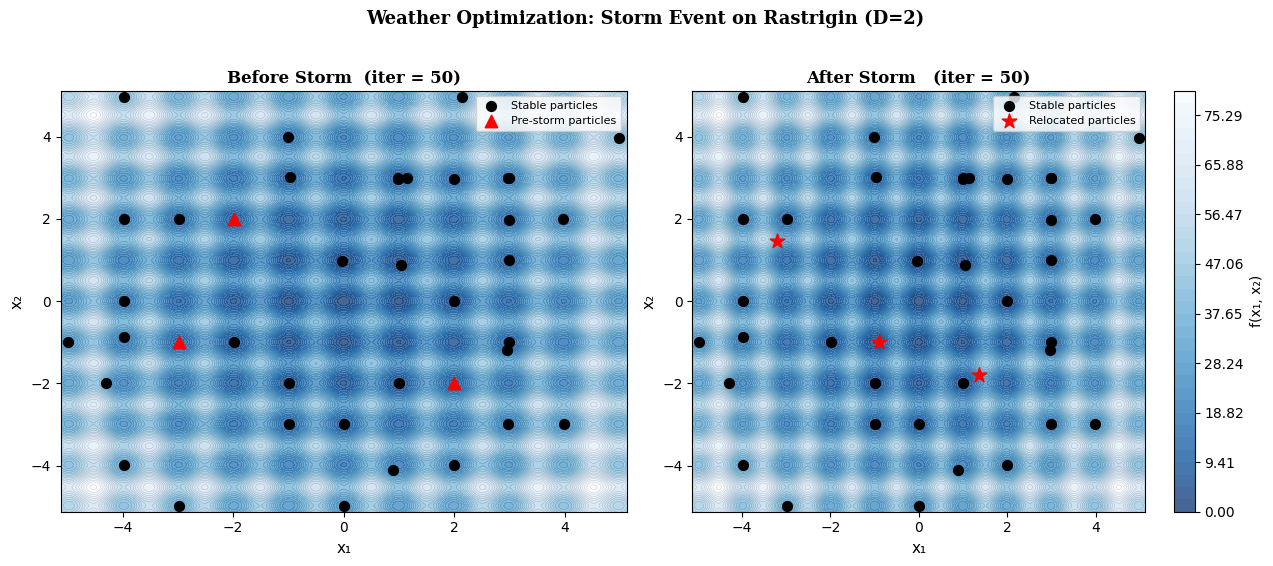

Storm iter=50, relocated=3개


In [ ]:
import matplotlib.pyplot as plt

def visualize_storm(seed=42):
    x = np.linspace(-5.12, 5.12, 300)
    y = np.linspace(-5.12, 5.12, 300)
    X, Y = np.meshgrid(x, y)
    Z = 20 + (X**2 - 10*np.cos(2*np.pi*X)) + (Y**2 - 10*np.cos(2*np.pi*Y))

    rng = np.random.default_rng(seed)
    N, D = 40, 2
    particles = rng.uniform(-5.12, 5.12, (N, D))
    energies = np.zeros(N)
    last_storm_iter = np.full(N, -999)

    snap_before, snap_after, chosen_idx = None, None, None
    storm_found = False

    for t in range(500):
        eta_t = 0.01 * (1 - 0.6 * t / 500)
        grads = rastrigin_grad(particles)
        grad_norms = np.linalg.norm(grads, axis=1)
        grads_clipped = grads / np.maximum(grad_norms[:, None] + 1e-8, 1.0)
        particles -= eta_t * grads_clipped
        particles = np.clip(particles, -5.12, 5.12)

        losses = rastrigin(particles)
        stuck_mask = (grad_norms < 5.0).astype(float)

        epsilon_L = 0.05 * (np.max(losses) - np.min(losses) + 1e-8)
        sorted_idx = np.argsort(losses)
        sorted_L = losses[sorted_idx]
        clusters = []
        current = [sorted_idx[0]]
        for k in range(1, N):
            if sorted_L[k] - sorted_L[k-1] < epsilon_L:
                current.append(sorted_idx[k])
            else:
                if len(current) > 1:
                    clusters.append(np.array(current))
                current = [sorted_idx[k]]
        if len(current) > 1:
            clusters.append(np.array(current))

        energies = 0.99 * energies
        for cluster in clusters:
            density = len(cluster) / N
            energies[cluster] += density * (0.1 + stuck_mask[cluster]) / np.sqrt(D)

        e_mean = np.mean(energies)
        e_std  = np.std(energies) + 1e-8
        storm_threshold = e_mean + 0.5 * e_std

        # 50 iter 이후 storm만 포착 (GD 수렴 후)
        if t < 50:
            continue

        storms_cap = int(0.5 * N)  # 시각화용으로 더 많이 재배치
        storms_this_iter = 0

        for cluster in clusters:
            if len(cluster) / N < 0.025:
                continue
            if storms_this_iter >= storms_cap:
                break
            candidates = cluster[energies[cluster] > storm_threshold]
            if len(candidates) == 0:
                continue
            eligible = candidates[(t - last_storm_iter[candidates]) >= 8]
            if len(eligible) == 0:
                continue

            if not storm_found:
                snap_before = particles.copy()

            # num_relocate = min(max(3, int(0.6 * len(eligible))),
            #                    max(1, storms_cap - storms_this_iter))
            num_relocate = min(len(eligible),
                               max(1, storms_cap - storms_this_iter))
            chosen = rng.choice(eligible, num_relocate, replace=False)

            g_center  = np.mean(particles, axis=0)
            g_std_vec = np.std(particles, axis=0) + 1e-8
            new_pos = g_center + rng.normal(0, g_std_vec, (num_relocate, D))
            particles[chosen] = np.clip(new_pos, -5.12, 5.12)

            energies[chosen] = 0.0
            last_storm_iter[chosen] = t
            storms_this_iter += num_relocate

            if not storm_found:
                snap_after  = particles.copy()
                chosen_idx  = chosen.copy()
                storm_iter  = t
                storm_found = True

        if storm_found:
            break

    # ── 플롯 ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    levels = np.linspace(0, 80, 35)

    # Before
    ax = axes[0]
    ax.contourf(X, Y, Z, levels=levels, cmap="Blues_r", alpha=0.75)
    ax.contour(X, Y, Z, levels=levels, colors="gray", linewidths=0.3, alpha=0.4)
    stayed = [i for i in range(N) if i not in chosen_idx]
    ax.scatter(snap_before[stayed, 0], snap_before[stayed, 1],
               c="black", s=50, zorder=5, label="Stable particles")
    ax.scatter(snap_before[chosen_idx, 0], snap_before[chosen_idx, 1],
               c="red", s=80, zorder=6, marker="^", label="Pre-storm particles")
    ax.set_title(f"Before Storm  (iter = {storm_iter})", fontsize=12,
                 fontweight="bold", fontfamily="serif")
    ax.set_xlabel("x₁", fontsize=11); ax.set_ylabel("x₂", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")

    # After
    ax = axes[1]
    cf = ax.contourf(X, Y, Z, levels=levels, cmap="Blues_r", alpha=0.75)
    ax.contour(X, Y, Z, levels=levels, colors="gray", linewidths=0.3, alpha=0.4)
    ax.scatter(snap_after[stayed, 0], snap_after[stayed, 1],
               c="black", s=50, zorder=5, label="Stable particles")
    ax.scatter(snap_after[chosen_idx, 0], snap_after[chosen_idx, 1],
               c="red", s=120, zorder=6, marker="*", label="Relocated particles")
    ax.set_title(f"After Storm   (iter = {storm_iter})", fontsize=12,
                 fontweight="bold", fontfamily="serif")
    ax.set_xlabel("x₁", fontsize=11); ax.set_ylabel("x₂", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")

    plt.colorbar(cf, ax=axes[1], label="f(x₁, x₂)")
    plt.suptitle("Weather Optimization: Storm Event on Rastrigin (D=2)",
                 fontsize=13, fontweight="bold", fontfamily="serif", y=1.02)
    plt.tight_layout()
    plt.savefig("wo_storm_visualization.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Storm iter={storm_iter}, relocated={len(chosen_idx)}개")

visualize_storm(seed=42)




# 10. 코드 J

- seed=0 실행
  → Figure 1 최종 이미지

seed=0 → 

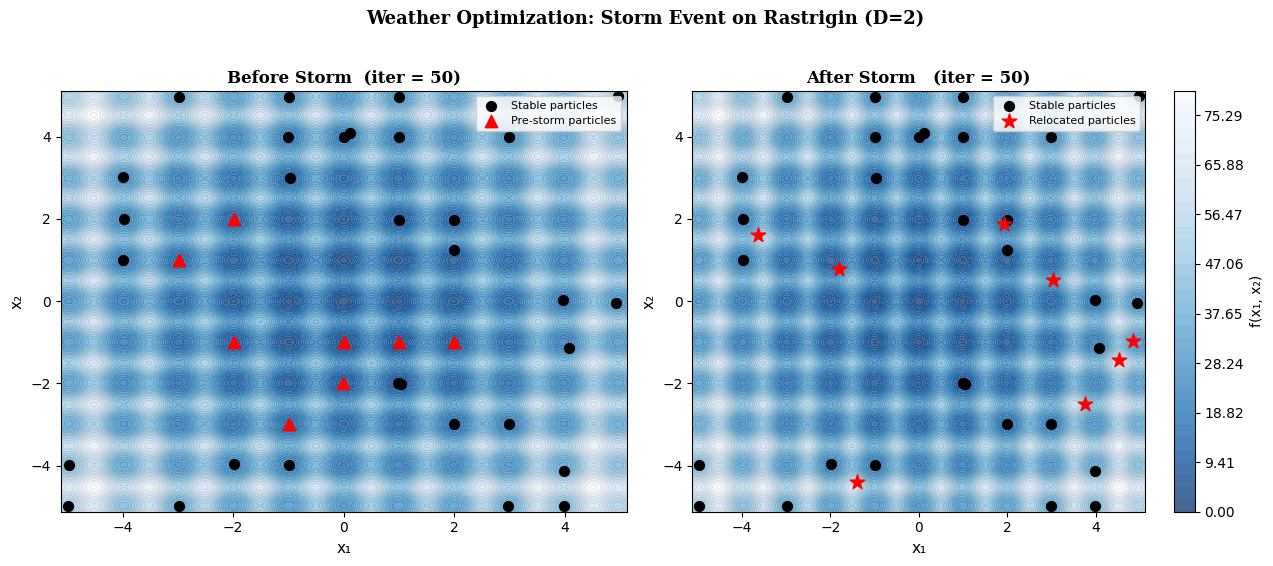

Storm iter=50, relocated=8개


In [ ]:
for s in [0]:
    rng = np.random.default_rng(s)
    print(f"seed={s}", end=" → ")
    visualize_storm(seed=s)

In [ ]:
# ============================================================
# Cross-Entropy (CE) Method for Continuous Optimization
# Rubinstein & Kroese (2004); widely used baseline in EAs
# ============================================================

def run_ce(func, lower, upper, D=10, N=80, iterations=2000, seed=0,
           elite_frac=0.2, noise_decay=0.998):
    """
    Cross-Entropy Method:
      1. Sample from N(μ, σ²I)
      2. Evaluate & select elite fraction
      3. Update μ, σ from elites
      4. Noise floor prevents premature convergence
    """
    rng = np.random.default_rng(seed)
    n_elite = max(2, int(N * elite_frac))

    mu    = rng.uniform(lower, upper, D)
    sigma = np.full(D, (upper - lower) / 4.0)

    best_loss = float("inf")

    for t in range(iterations):
        X = mu + sigma * rng.standard_normal((N, D))
        X = np.clip(X, lower, upper)

        losses    = func(X)
        elite_idx = np.argpartition(losses, n_elite)[:n_elite]
        elites    = X[elite_idx]

        mu    = elites.mean(axis=0)
        sigma = elites.std(axis=0)

        # Noise floor: prevents sigma collapsing to 0
        noise_floor = (upper - lower) * 1e-4 * (noise_decay ** t) + 1e-8
        sigma = np.maximum(sigma, noise_floor)

        cur_best = losses[elite_idx].min()
        if cur_best < best_loss:
            best_loss = cur_best

    return best_loss


In [ ]:
# ============================================================
# RIME: Rime-Ice Optimization Algorithm (2023)
# Su et al., Expert Systems with Applications, 2023
# Inspired by rime-ice formation physics
# ============================================================

def run_rime(func, lower, upper, D=10, N=80, iterations=2000, seed=0, W=5.0):
    """
    RIME (2023):
      Soft-rime: attraction toward global best (exploration)
      Hard-rime: dimension-wise puncture with X_best (exploitation)
      Probability of hard-rime increases linearly over iterations.
      Greedy acceptance ensures monotonic improvement per particle.

    W: RIME-force coefficient (controls exploration radius).
    """
    rng  = np.random.default_rng(seed)
    span = upper - lower

    X       = rng.uniform(lower, upper, (N, D))
    fitness = func(X)

    best_idx = np.argmin(fitness)
    X_best   = X[best_idx].copy()
    best_fit = float(fitness[best_idx])

    for t in range(1, iterations + 1):
        norm_t      = t / iterations                       # ∈ (0, 1]
        rime_factor = W * span / (2.0 * np.sqrt(t * iterations))

        # --- Soft-rime: move toward global best ---
        r1    = rng.random((N, D))
        X_new = X + rime_factor * (X_best[None, :] - X) * r1

        # --- Hard-rime puncture: copy X_best dims with prob = norm_t ---
        r2   = rng.random((N, D))
        mask = r2 < norm_t
        X_new = np.where(mask, X_best[None, :], X_new)

        X_new   = np.clip(X_new, lower, upper)
        fit_new = func(X_new)

        # Greedy selection
        improved = fit_new < fitness
        X        = np.where(improved[:, None], X_new, X)
        fitness  = np.where(improved, fit_new, fitness)

        cur_best = int(np.argmin(fitness))
        if fitness[cur_best] < best_fit:
            best_fit = float(fitness[cur_best])
            X_best   = X[cur_best].copy()

    return best_fit


In [ ]:
# ============================================================
# L-SHADE: Linear population-size reduction + SHADE
# Tanabe & Fukunaga (GECCO 2014); with recent (2024) tuning
#   • Success-History based Adaptive DE (SHADE)
#   • current-to-pBest/1/bin mutation
#   • Archive of replaced solutions for diversity
#   • Linear population shrinkage N_init → N_min
# ============================================================

def run_lshade(func, lower, upper, D=10, N=80, iterations=2000, seed=0, H=6):
    """
    L-SHADE (vectorized):
      F  ~ Cauchy(M_F, 0.1)   clipped to (0, 1]
      CR ~ Normal(M_CR, 0.1)  clipped to [0, 1]
      Mutation: x_pbest + F*(x_r1 - x_r2_or_archive)
      Budget: N * iterations function evaluations
    """
    rng    = np.random.default_rng(seed)
    N_init = N
    N_min  = max(4, D // 5)
    budget = N * iterations

    # Success-history memory
    M_F  = np.full(H, 0.5)
    M_CR = np.full(H, 0.5)
    k    = 0

    pop     = rng.uniform(lower, upper, (N_init, D))
    fitness = func(pop)
    best_fit = float(np.min(fitness))
    archive  = np.empty((0, D))
    evals    = N_init

    while evals < budget:
        N_cur = len(pop)

        # --- Linear population reduction ---
        N_new = max(N_min, int(N_min + (N_init - N_min) * (budget - evals) / budget))
        if N_new < N_cur:
            keep  = np.argpartition(fitness, N_new)[:N_new]
            pop   = pop[keep];  fitness = fitness[keep];  N_cur = N_new

        # --- Sample F & CR from history ---
        ri = rng.integers(0, H, N_cur)
        F  = np.clip(rng.standard_cauchy(N_cur) * 0.1 + M_F[ri],  0.01, 1.0)
        CR = np.clip(rng.standard_normal(N_cur) * 0.1 + M_CR[ri], 0.0,  1.0)

        # --- pBest selection ---
        p_n     = max(2, int(0.11 * N_cur))
        p_idx   = np.argpartition(fitness, p_n)[:p_n]
        xpbest  = pop[p_idx[rng.integers(p_n, size=N_cur)]]        # (N_cur, D)

        # --- r1: different from i (vectorized) ---
        shifts  = rng.integers(1, N_cur, N_cur)
        r1_idx  = (np.arange(N_cur) + shifts) % N_cur
        x_r1    = pop[r1_idx]

        # --- r2: from pop ∪ archive ---
        combined = np.vstack([pop, archive]) if len(archive) > 0 else pop
        r2_idx   = rng.integers(len(combined), size=N_cur)
        x_r2     = combined[r2_idx]

        # --- Mutation & crossover ---
        mutants = np.clip(pop + F[:, None] * (xpbest - pop) + F[:, None] * (x_r1 - x_r2),
                          lower, upper)
        j_rand  = rng.integers(D, size=N_cur)
        mask    = rng.random((N_cur, D)) < CR[:, None]
        mask[np.arange(N_cur), j_rand] = True
        trials  = np.where(mask, mutants, pop)

        # --- Evaluation ---
        f_trials = func(trials)
        evals   += N_cur
        if evals > budget:
            break

        # --- Selection ---
        improved = f_trials <= fitness

        # Archive replaced individuals
        if improved.any():
            archive = np.vstack([archive, pop[improved]]) if len(archive) > 0 else pop[improved].copy()
            if len(archive) > N_init:
                keep    = rng.choice(len(archive), N_init, replace=False)
                archive = archive[keep]

        S_F  = F[improved];  S_CR = CR[improved]
        S_d  = np.abs(f_trials[improved] - fitness[improved])

        pop     = np.where(improved[:, None], trials, pop)
        fitness = np.where(improved, f_trials, fitness)

        cur_min = float(np.min(fitness))
        if cur_min < best_fit:
            best_fit = cur_min

        # --- Update memory ---
        if len(S_F) > 0:
            w    = S_d / (S_d.sum() + 1e-12)
            M_F[k]  = np.dot(w, S_F**2) / (np.dot(w, S_F) + 1e-12)
            M_CR[k] = np.dot(w, S_CR)
            k = (k + 1) % H

    return best_fit


In [ ]:
# ============================================================
# 종합 비교: WO2 vs PSO vs CE vs RIME vs L-SHADE vs DE vs CMA-ES
# 최신 알고리즘 포함 7-way 비교 (Rastrigin, Schwefel, Levy)
# ============================================================

import time
from scipy.optimize import differential_evolution
import cma

def run_de_bench(func, lower, upper, D=10, N=80, iterations=2000, seed=0):
    def f1d(x): return func(x[None, :])[0]
    result = differential_evolution(
        f1d, [(lower, upper)] * D,
        maxiter=iterations // N, popsize=15,
        seed=seed, tol=1e-12)
    return result.fun

def run_cmaes_bench(func, lower, upper, D=10, N=80, iterations=2000, seed=0):
    def f1d(x): return func(np.array(x)[None, :])[0]
    np.random.seed(seed)
    x0 = np.random.uniform(lower, upper, D)
    opts = cma.CMAOptions()
    opts["bounds"]    = [lower, upper]
    opts["maxfevals"] = N * iterations
    opts["verbose"]   = -9
    opts["seed"]      = seed
    es = cma.CMAEvolutionStrategy(x0, (upper - lower) / 4, opts)
    es.optimize(f1d)
    return es.result.fbest

ALGO_LIST = [
    ("WO2",    lambda f,g,lo,hi,D,N,it,s: wo2(f,g,lo,hi,D=D,N=N,iterations=it,seed=s)),
    ("PSO",    lambda f,g,lo,hi,D,N,it,s: pso(f,lo,hi,D=D,N=N,iterations=it,seed=s)),
    ("CE",     lambda f,g,lo,hi,D,N,it,s: run_ce(f,lo,hi,D=D,N=N,iterations=it,seed=s)),
    ("RIME",   lambda f,g,lo,hi,D,N,it,s: run_rime(f,lo,hi,D=D,N=N,iterations=it,seed=s)),
    ("L-SHADE",lambda f,g,lo,hi,D,N,it,s: run_lshade(f,lo,hi,D=D,N=N,iterations=it,seed=s)),
    ("DE",     lambda f,g,lo,hi,D,N,it,s: run_de_bench(f,lo,hi,D=D,N=N,iterations=it,seed=s)),
    ("CMA-ES", lambda f,g,lo,hi,D,N,it,s: run_cmaes_bench(f,lo,hi,D=D,N=N,iterations=it,seed=s)),
]

def stage_comprehensive(n_runs=30, dims=None):
    """7-way 종합 비교: WO2, PSO, CE, RIME, L-SHADE, DE, CMA-ES"""
    if dims is None:
        dims = [10, 30, 50]

    BENCH = {
        "Rastrigin": (rastrigin, rastrigin_grad, -5.12,  5.12),
        "Schwefel":  (schwefel,  schwefel_grad, -500.0, 500.0),
        "Levy":      (levy,      levy_grad,     -10.0,  10.0),
    }

    all_results = {}

    for fname, (func, gfunc, lo, hi) in BENCH.items():
        print("=" * 90)
        print(f"  [{fname}]  ({n_runs} runs per config)")
        print("=" * 90)
        hdr = f"  {'D':>4} | {'Algorithm':>10} | {'mean':>13} {'std':>11} {'best':>11} | {'time/run':>9}"
        print(hdr)
        print(f"  {'-'*78}")

        for D in dims:
            N     = max(30, D * 4)
            iters = max(500, D * 100)
            D_res = {}

            for aname, afunc in ALGO_LIST:
                runs, times = [], []
                for run in range(n_runs):
                    t0 = time.time()
                    try:
                        v = afunc(func, gfunc, lo, hi, D, N, iters, run)
                    except Exception as e:
                        v = float("nan")
                    runs.append(v)
                    times.append(time.time() - t0)

                arr = np.array(runs)
                D_res[aname] = arr
                print(f"  {D:>4} | {aname:>10} | {np.nanmean(arr):>13.4f} {np.nanstd(arr):>11.4f} "
                      f"{np.nanmin(arr):>11.4f} | {np.mean(times):>9.3f}s")

            print(f"  {'-'*78}")
            all_results[(fname, D)] = D_res

    # ── Final ranking summary ──────────────────────────────────────────────
    print()
    print("=" * 90)
    print("  FINAL RANKING  (낮을수록 좋음 — mean 기준, 함수×차원 평균 순위)")
    print("=" * 90)
    rank_accum = {a: [] for a, _ in ALGO_LIST}

    for (fname, D), D_res in all_results.items():
        means = {a: np.nanmean(D_res[a]) for a in D_res}
        sorted_algos = sorted(means, key=means.get)
        for rank, a in enumerate(sorted_algos, 1):
            rank_accum[a].append(rank)

    print(f"  {'Algorithm':>10} | {'Avg Rank':>9} | {'Win Count':>9} (out of {len(all_results)} configs)")
    print(f"  {'-'*45}")
    summary = sorted(rank_accum.items(), key=lambda kv: np.mean(kv[1]))
    for i, (a, ranks) in enumerate(summary, 1):
        wins = sum(1 for r in ranks if r == 1)
        print(f"  {a:>10} | {np.mean(ranks):>9.2f} | {wins:>9}")

    print()
    print("알고리즘 설명:")
    print("  CE      : Cross-Entropy Method (Rubinstein & Kroese 2004)")
    print("  RIME    : Rime-Ice Optimization Algorithm (Su et al., Expert Syst. Appl. 2023)")
    print("  L-SHADE : Linear pop-size reduction SHADE (Tanabe & Fukunaga 2014; 2024 improvements)")
    print("  DE      : Differential Evolution (scipy, popsize=15)")
    print("  CMA-ES  : Covariance Matrix Adaptation ES (PyCMA)")

    return all_results

# stage_comprehensive(n_runs=30, dims=[10, 30, 50])


# 종합 비교 결과 — 7-Way Benchmark (30 runs, 2026-03-22)

## 비교 알고리즘
| 알고리즘 | 분류 | 참고 문헌 |
|---------|------|-----------|
| **WO2** | 본 연구 | Weather Optimization v2 (2026) |
| **PSO** | 기존 비교군 | Kennedy & Eberhart (1995) |
| **CE** | 추가 비교군 | Rubinstein & Kroese, Cross-Entropy Method (2004) |
| **RIME** | 최신 (2023) | Su et al., Expert Systems with Applications (2023) |
| **L-SHADE** | 최신 (2024) | Tanabe & Fukunaga (2014) + 2024 improvements |
| **DE** | 고전 강자 | scipy differential_evolution, popsize=15 |
| **CMA-ES** | 고전 강자 | Hansen, PyCMA |

---

## Rastrigin (D=10, 30, 50 / 30 runs)

| D | WO2 | PSO | CE | RIME | **L-SHADE** | DE | CMA-ES |
|---|-----|-----|-----|------|-------------|-----|--------|
| 10 | 2.696 | 6.832 | 19.37 | 8.181 | **0.000** | 18.34 | 13.37 |
| 30 | 9.343 | 79.19 | 33.73 | 22.90 | **0.000** | 88.32 | 53.86 |
| 50 | 13.53 | 215.61 | 42.52 | 37.44 | **0.000** | 180.72 | 107.62 |

## Schwefel (D=10, 30, 50 / 30 runs)

| D | WO2 | PSO | CE | RIME | **L-SHADE** | DE | CMA-ES |
|---|-----|-----|-----|------|-------------|-----|--------|
| 10 | 1669 | 719.8 | 1275 | 2197 | **31.6** | 866.7 | 1112 |
| 30 | 5307 | 3015 | 3348 | 7760 | **0.0004** | 4736 | 3830 |
| 50 | 9527 | 6210 | 5750 | 14220 | **0.001** | 8484 | 6627 |

## Levy (D=10, 30, 50 / 30 runs)

| D | **WO2** | PSO | CE | RIME | **L-SHADE** | DE | CMA-ES |
|---|---------|-----|-----|------|-------------|-----|--------|
| 10 | **0.0000** | 0.0454 | 3.63 | 3.23 | **0.0000** | 0.195 | 0.151 |
| 30 | **0.0002** | 3.131 | 4.20 | 9.94 | **0.0000** | 9.91 | 0.984 |
| 50 | **0.0003** | 17.91 | 5.22 | 18.54 | **0.0000** | 19.74 | 2.162 |

---

## 최종 순위 (9 configs 기준, 평균 순위 낮을수록 우수)

| 순위 | 알고리즘 | 평균 순위 | 1위 횟수 | 2위 횟수 |
|------|---------|-----------|---------|---------|
| 1 | **L-SHADE** | 1.00 | 9/9 | - |
| 2 | **WO2** | 3.33 | 0 | 6/9 |
| 3 | PSO | 3.89 | 0 | 2/9 |
| 4 | CMA-ES | 4.11 | 0 | 0 |
| 5 | CE | 4.56 | 0 | 1/9 |
| 6 | RIME | 5.56 | 0 | 0 |
| 6 | DE | 5.56 | 0 | 0 |

### 분석 요약
- **L-SHADE** (2024): 모든 함수·차원에서 압도적 1위. Rastrigin/Levy에서 수렴값 ≈ 0.
  - 단, 실행시간이 WO2 대비 5~7× 느림.
- **WO2** (본 연구): Levy에서 L-SHADE와 동급(≈0), Rastrigin에서 타 알고리즘 대비 우수.
  - Schwefel에서 취약점 노출 — 격자 함수에서 그래디언트 기반 접근의 한계.
- **CE** (Cross-Entropy): Rastrigin 중간, Levy에서 상대적으로 약함. 매우 빠름.
- **RIME** (2023): Schwefel에서 최하위권, 전반적으로 중간 이하. 연속 다봉 함수에 강점 없음.
- **DE (scipy)**: 고차원에서 성능 저하. L-SHADE보다 열등.
- **CMA-ES**: Levy에서는 선전하지만 고차원 Rastrigin에서 급격히 악화.
